In [40]:
# ── Global paths ──────────────────────────────────────────────────────────────
SWEAT_0 = "../20260404-experiment/sweat.csv"   
SWEAT_1 = "../20260405-experiment/sweat.csv"   # Reference — clean wiring
SWEAT_2 = "../20260424-experiment/sweat.csv"
SWEAT_3 = "../20260426-experiment/sweat.csv"
SWEAT_4 = "../20260427-experiment/sweat_1.csv"
SWEAT_5 = "../20260427-experiment/sweat_2.csv"
SWEAT_6 = "../20260429-experiment/sweat_1.csv"
SWEAT_7 = "../20260429-experiment/sweat_2.csv"

BLOOD_0 = "../20260406-experiment/1.5_blood.csv"
BLOOD_1 = "../20260406-experiment/1.5_blood_2.csv"
BLOOD_2 = "../20260421-experiment/1.5_blood.csv"
BLOOD_3 = "../20260421-experiment/1.5_blood_2.csv"
BLOOD_4 = "../20260422-experiment/1.5_blood.csv"
BLOOD_5 = "../20260422-experiment/1.5_blood_2.csv"
BLOOD_6 = "../20260424-experiment/1.5_blood.csv"
BLOOD_7 = "../20260424-experiment/1.5_blood_2.csv"
BLOOD_8 = "../20260426-experiment/1.5_blood.csv"
BLOOD_9 = "../20260426-experiment/1.5_blood_2.csv"

MIX_75_75_1  = "../20260517-experiment/75sweat75blood.csv" # this mean mix samples. 0.75 ml of sweat and 0.75 ml of blood. MIX_SWEAT_BLOOD.
MIX_120_30_1 = "../20260517-experiment/120sweat30blood.csv"
MIX_140_10_1 = "../20260518-experiment/140sweat10blood.csv"

MIX_75_75_2  = "../20260518-experiment/75sweat75blood.csv"
MIX_120_30_2 = "../20260519-experiment/120sweat30blood.csv"
MIX_140_10_2 = "../20260519-experiment/140sweat10blood.csv"

MIX_75_75_3  = "../20260522-experiment/75sweat75blood.csv"
MIX_120_30_3 = "../20260522-experiment/120sweat30blood.csv"
MIX_140_10_3 = "../20260522-experiment/140sweat_10blood.csv"

MIX_75_75_4  = "../20260523-experiment/75sweat75blood.csv"
MIX_120_30_4 = "../20260523-experiment/120sweat30blood.csv"
MIX_140_10_4 = "../20260523-experiment/140sweat_10blood.csv"

MIX_75_75_5  = "../20260525-experiment/75sweat75blood.csv"
MIX_120_30_5 = "../20260525-experiment/120sweat30blood.csv"
MIX_140_10_5 = "../20260525-experiment/140sweat_10blood.csv"



BLOOD_TEST_0 = "../20260426-experiment/1.5_blood.csv"
SWEAT_TEST_0 = ""

MEMS = ["voc", "nh3", "hcho"]

# Smoothing params
ROLLING_WINDOW = 20   
SG_WINDOW      = 31   # Savitzky-Golay window (must be odd)
SG_POLY        = 3    # Savitzky-Golay polynomial order

# SWEAT_0 defect: NH3 zero runs (rows where NH3 = 0.0 V)
SWEAT_0_DEFECT_ZERO_RUNS = [(3912, 3983), (4012, 4036)]  # (start_row, end_row)


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

def load(path, t_min=0, t_max=None):
    df = pd.read_csv(path, parse_dates=["wall_time"])
    df["elapsed_s"] = (df["wall_time"] - df["wall_time"].iloc[0]).dt.total_seconds()
    for col in MEMS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df[df["elapsed_s"] >= t_min]
    if t_max is not None:
        df = df[df["elapsed_s"] < t_max]
    return df.reset_index(drop=True)

SWEAT_1_RESET_S = 4000   # Reset event — recording restarted, sensor stayed powered

sweat_0  = load(SWEAT_0, t_max=4000)
sweat_1  = load(SWEAT_1)
sweat_1a = load(SWEAT_1, t_max=SWEAT_1_RESET_S)
sweat_1b = load(SWEAT_1, t_min=SWEAT_1_RESET_S)
sweat_1b = sweat_1b.assign(
    elapsed_s=sweat_1b["elapsed_s"] - sweat_1b["elapsed_s"].iloc[0]
)
sweat_2  = load(SWEAT_2)
sweat_3  = load(SWEAT_3)
sweat_4  = load(SWEAT_4)
sweat_5  = load(SWEAT_5)
sweat_6  = load(SWEAT_6, t_min=500)
sweat_7  = load(SWEAT_7)

blood_0  = load(BLOOD_0)
blood_1  = load(BLOOD_1, t_min=1750)
blood_2  = load(BLOOD_2)
blood_3  = load(BLOOD_3)
blood_4  = load(BLOOD_4)
blood_5  = load(BLOOD_5)
blood_6  = load(BLOOD_6, t_min=500)
blood_7  = load(BLOOD_7)
blood_8  = load(BLOOD_8, t_min=500)
blood_9  = load(BLOOD_9)

mix_75_75_1  = load(MIX_75_75_1,  t_min=500)
mix_75_75_2  = load(MIX_75_75_2)
mix_75_75_3  = load(MIX_75_75_3)
mix_75_75_4  = load(MIX_75_75_4)
mix_75_75_5  = load(MIX_75_75_5)
mix_120_30_1 = load(MIX_120_30_1)
mix_120_30_2 = load(MIX_120_30_2)
mix_120_30_3 = load(MIX_120_30_3)
mix_120_30_4 = load(MIX_120_30_4)
mix_120_30_5 = load(MIX_120_30_5)
mix_140_10_1 = load(MIX_140_10_1)
mix_140_10_2 = load(MIX_140_10_2)
mix_140_10_3 = load(MIX_140_10_3, t_min=500)
mix_140_10_4 = load(MIX_140_10_4, t_min=500)
mix_140_10_5 = load(MIX_140_10_5, t_min=500)

print(f"{'Dataset':<14}  {'Rows':>6}  {'Duration':>10}")
print("-" * 36)
for name, df in [
    ("sweat_1a",     sweat_1a),    ("sweat_1b",     sweat_1b),
    ("sweat_2",      sweat_2),     ("sweat_3",      sweat_3),
    ("sweat_4",      sweat_4),     ("sweat_5",      sweat_5),
    ("sweat_6",      sweat_6),     ("sweat_7",      sweat_7),
    ("blood_0",      blood_0),     ("blood_1",      blood_1),
    ("blood_2",      blood_2),     ("blood_3",      blood_3),
    ("blood_4",      blood_4),     ("blood_5",      blood_5),
    ("blood_6",      blood_6),     ("blood_7",      blood_7),
    ("blood_8",      blood_8),     ("blood_9",      blood_9),
    ("mix_75_75_1",  mix_75_75_1), ("mix_75_75_2",  mix_75_75_2),
    ("mix_75_75_3",  mix_75_75_3), ("mix_75_75_4",  mix_75_75_4),
    ("mix_75_75_5",  mix_75_75_5),
    ("mix_120_30_1", mix_120_30_1),("mix_120_30_2", mix_120_30_2),
    ("mix_120_30_3", mix_120_30_3),("mix_120_30_4", mix_120_30_4),
    ("mix_120_30_5", mix_120_30_5),
    ("mix_140_10_1", mix_140_10_1),("mix_140_10_2", mix_140_10_2),
    ("mix_140_10_3", mix_140_10_3),("mix_140_10_4", mix_140_10_4),
    ("mix_140_10_5", mix_140_10_5),
]:
    print(f"{name:<14}  {len(df):>6}  {df['elapsed_s'].iloc[-1]:>8.0f} s")

Dataset           Rows    Duration
------------------------------------
sweat_1a          3909      4000 s
sweat_1b          2390      2446 s
sweat_2           5393      5521 s
sweat_3           5106      5227 s
sweat_4           4930      5042 s
sweat_5           2723      2786 s
sweat_6           5416      6133 s
sweat_7           3543      3659 s
blood_0           3666      3753 s
blood_1           1908      3703 s
blood_2           2882      2987 s
blood_3           3324      3484 s
blood_4           2357      2473 s
blood_5           3598      3746 s
blood_6           3383      3963 s
blood_7           3486      3568 s
blood_8           3216      3791 s
blood_9           4093      4190 s
mix_75_75_1       6184      6850 s
mix_75_75_2       5567      5699 s
mix_75_75_3       2881      2961 s
mix_75_75_4       4003      4097 s
mix_75_75_5       4178      4334 s
mix_120_30_1      2857      2924 s
mix_120_30_2      3169      3313 s
mix_120_30_3      2866      2946 s
mix_120_30_4      

## SWEAT_0 Defect Investigation

**Problem:** The NH3 sensor wire was miswired to the VOC ADC pin from the beginning of the session — not during recording.

**Effect on NH3:** Pin 34 (NH3) was floating/unconnected → reads `0.0 V` for large blocks of the session.

**Effect on VOC:** The NH3 wire loading pin 35 (VOC) might suppress the VOC readings.

**Conclusion:** SWEAT_0 VOC and NH3 channels are both unreliable and should not be used for model training.


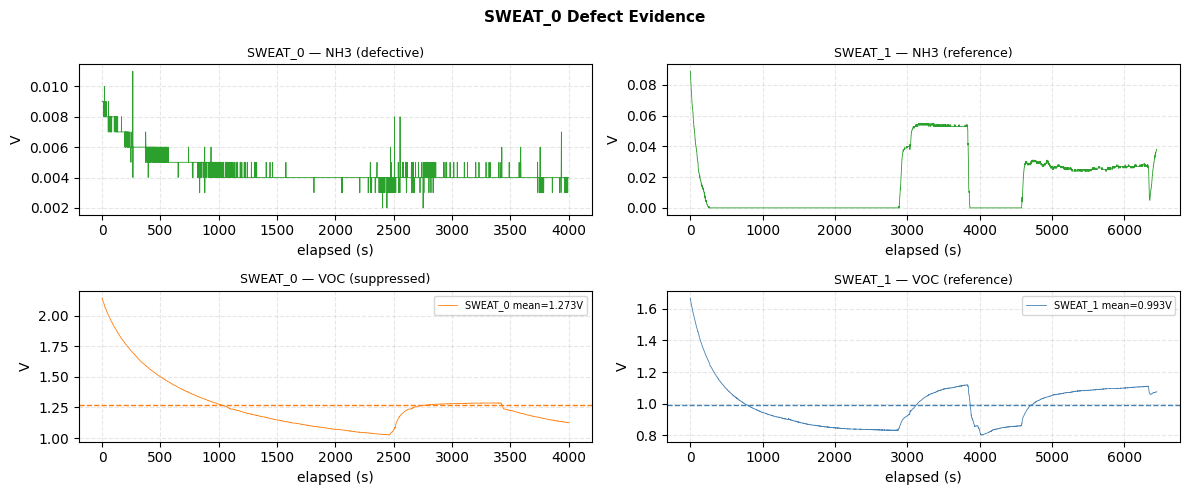

NH3 zeros in SWEAT_0: 0/3874 (0.0%)
VOC mean — SWEAT_0: 1.273 V   SWEAT_1: 0.993 V  (diff: -0.280 V)


In [42]:
fig, axes = plt.subplots(2, 2, figsize=(12, 5))
fig.suptitle("SWEAT_0 Defect Evidence", fontsize=11, fontweight="bold")

# Detect zero-run time spans directly from the trimmed dataframe
def zero_time_spans(df, col):
    is_zero = (df[col] == 0.0)
    spans = []
    in_run = False
    for i, val in enumerate(is_zero):
        if val and not in_run:
            in_run = True
            t_start = df["elapsed_s"].iloc[i]
        elif not val and in_run:
            in_run = False
            spans.append((t_start, df["elapsed_s"].iloc[i - 1]))
    if in_run:
        spans.append((t_start, df["elapsed_s"].iloc[-1]))
    return spans

# NH3: stuck-at-zero blocks (defective)
ax = axes[0, 0]
ax.plot(sweat_0["elapsed_s"], sweat_0["nh3"], color="tab:green", linewidth=0.6)
for t0, t1 in zero_time_spans(sweat_0, "nh3"):
    ax.axvspan(t0, t1, color="red", alpha=0.2, label="stuck at 0 V")
ax.set_title("SWEAT_0 — NH3 (defective)", fontsize=9)
ax.set_ylabel("V"); ax.set_xlabel("elapsed (s)")
ax.grid(True, alpha=0.3, linestyle="--")
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles[:1], labels[:1], fontsize=7)

# NH3 reference (full signal)
ax = axes[0, 1]
ax.plot(sweat_1["elapsed_s"], sweat_1["nh3"], color="tab:green", linewidth=0.6)
ax.set_title("SWEAT_1 — NH3 (reference)", fontsize=9)
ax.set_ylabel("V"); ax.set_xlabel("elapsed (s)")
ax.grid(True, alpha=0.3, linestyle="--")

# VOC defective
ax = axes[1, 0]
ax.plot(sweat_0["elapsed_s"], sweat_0["voc"], color="tab:orange", linewidth=0.6, label=f"SWEAT_0 mean={sweat_0['voc'].mean():.3f}V")
ax.axhline(sweat_0["voc"].mean(), color="tab:orange", linestyle="--", linewidth=1)
ax.set_title("SWEAT_0 — VOC (suppressed)", fontsize=9)
ax.set_ylabel("V"); ax.set_xlabel("elapsed (s)")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3, linestyle="--")

# VOC reference
ax = axes[1, 1]
ax.plot(sweat_1["elapsed_s"], sweat_1["voc"], color="steelblue", linewidth=0.6, label=f"SWEAT_1 mean={sweat_1['voc'].mean():.3f}V")
ax.axhline(sweat_1["voc"].mean(), color="steelblue", linestyle="--", linewidth=1)
ax.set_title("SWEAT_1 — VOC (reference)", fontsize=9)
ax.set_ylabel("V"); ax.set_xlabel("elapsed (s)")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

nh3_zeros = (sweat_0["nh3"] == 0.0).sum()
print(f"NH3 zeros in SWEAT_0: {nh3_zeros}/{len(sweat_0)} ({100*nh3_zeros/len(sweat_0):.1f}%)")
print(f"VOC mean — SWEAT_0: {sweat_0['voc'].mean():.3f} V   SWEAT_1: {sweat_1['voc'].mean():.3f} V  (diff: {sweat_1['voc'].mean()-sweat_0['voc'].mean():.3f} V)")


## Initial Visualization

Raw signal with rolling average and Savitzky-Golay smoothing overlaid.
SWEAT_0 is included for completeness but its VOC/NH3 channels are defective (see above).


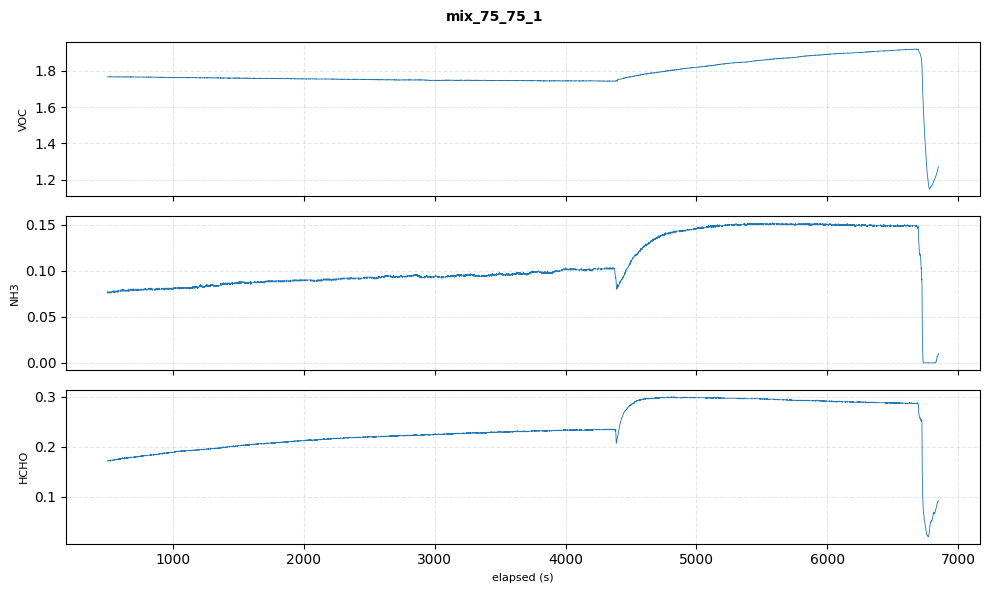

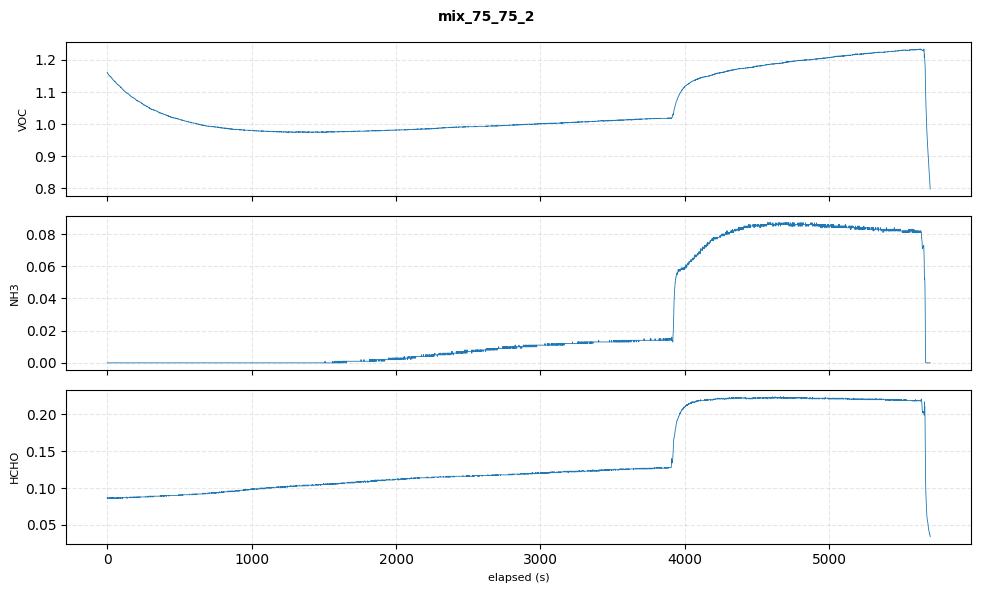

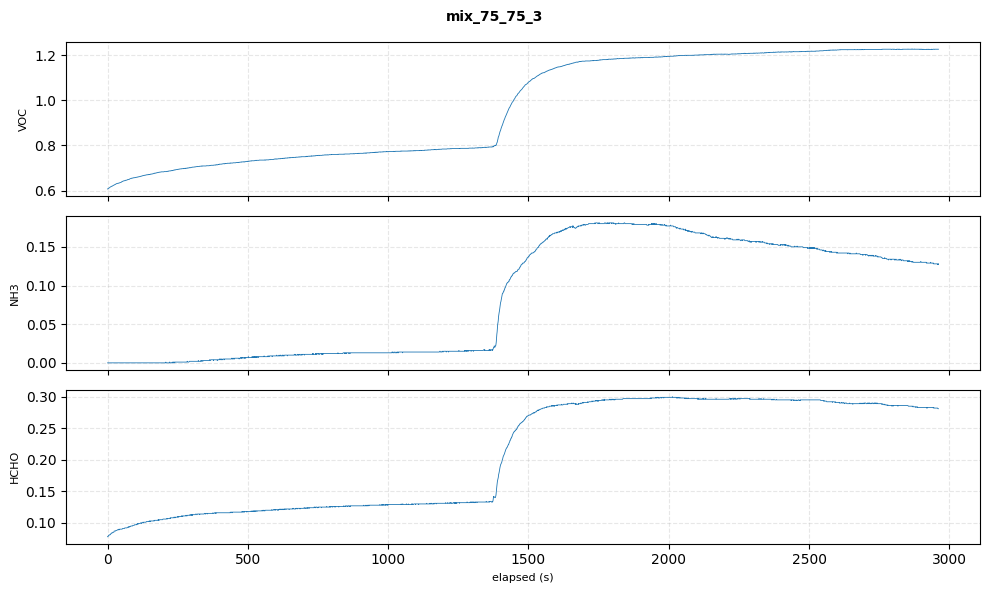

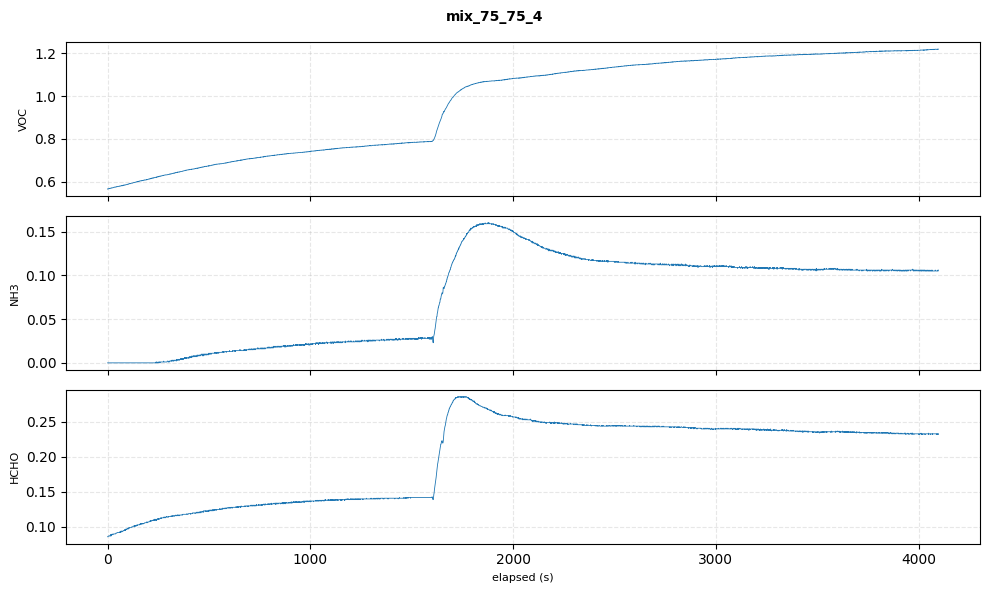

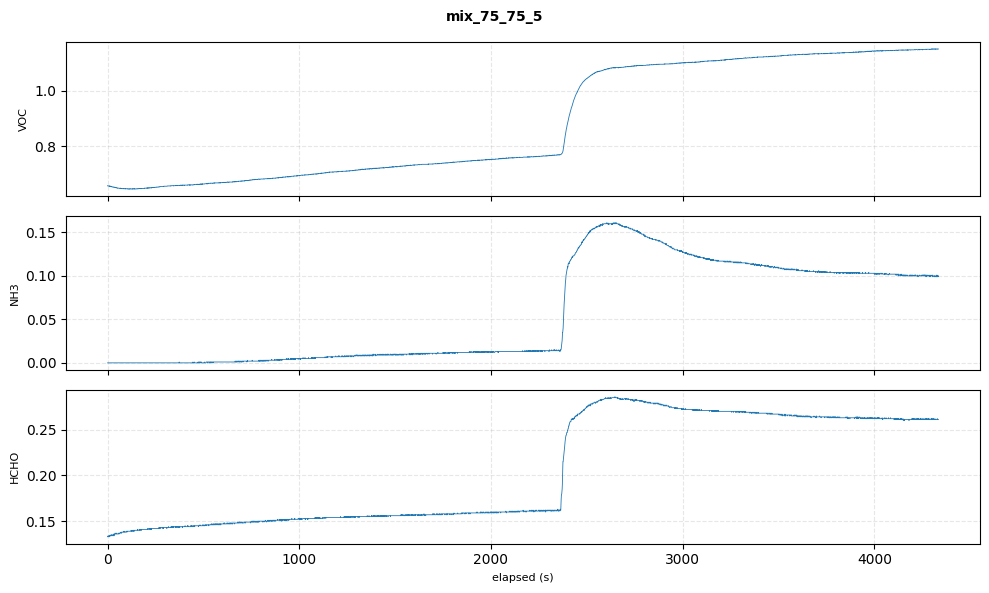

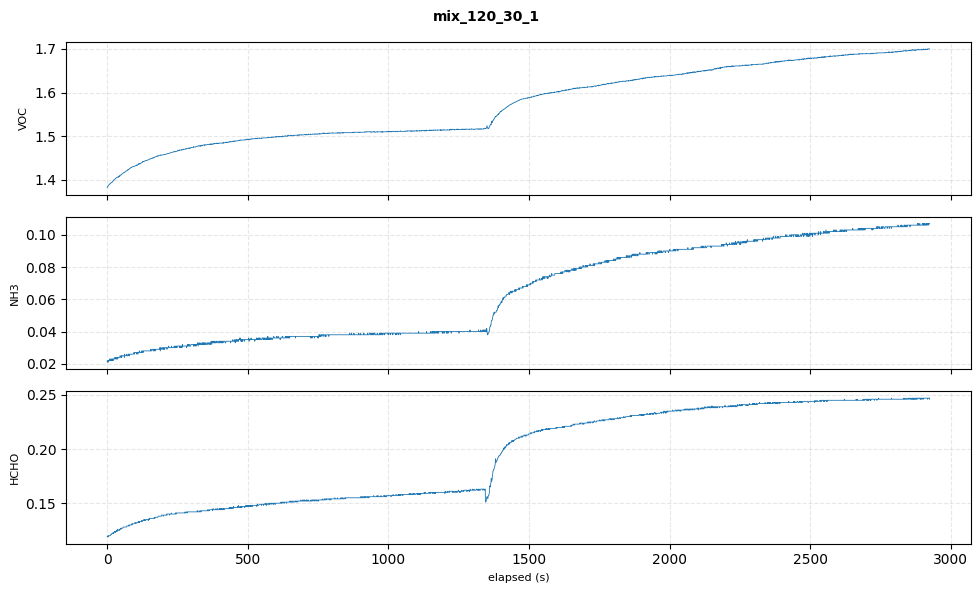

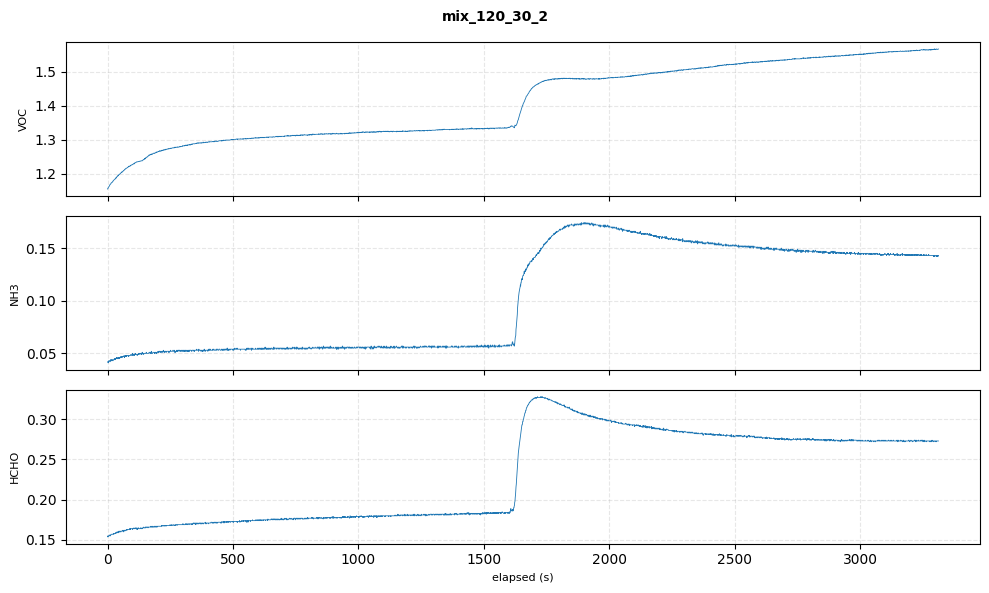

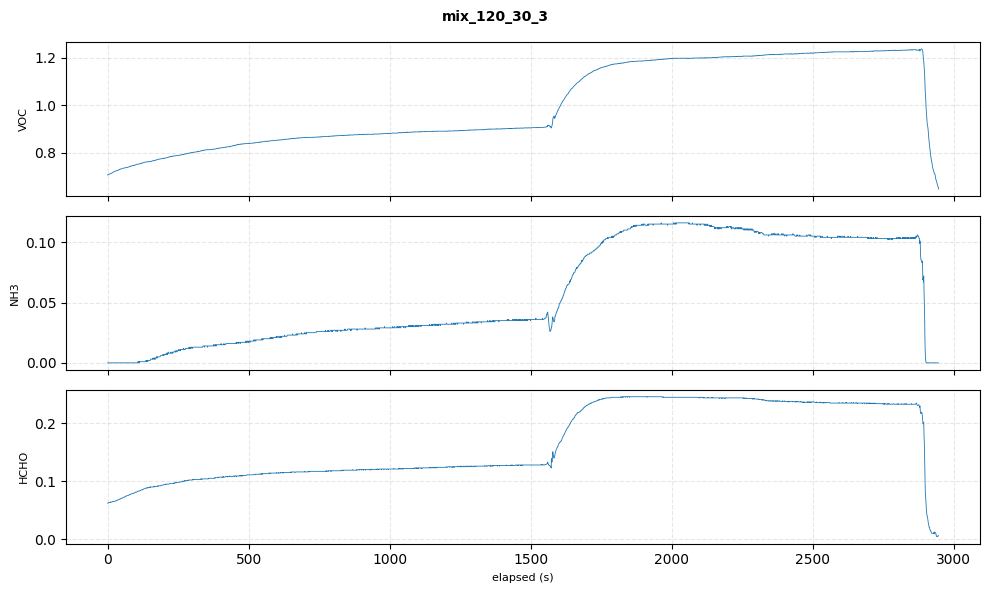

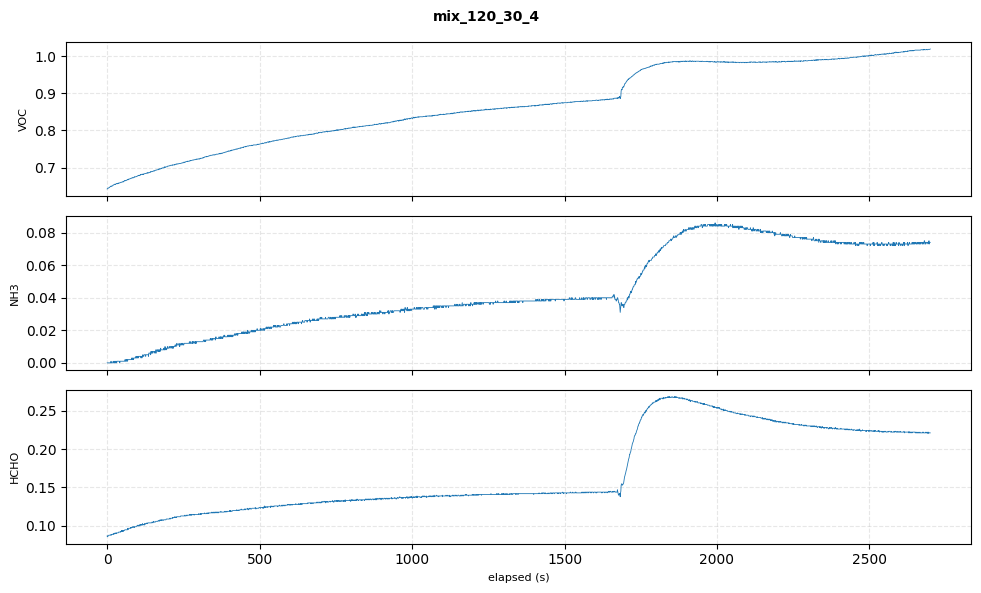

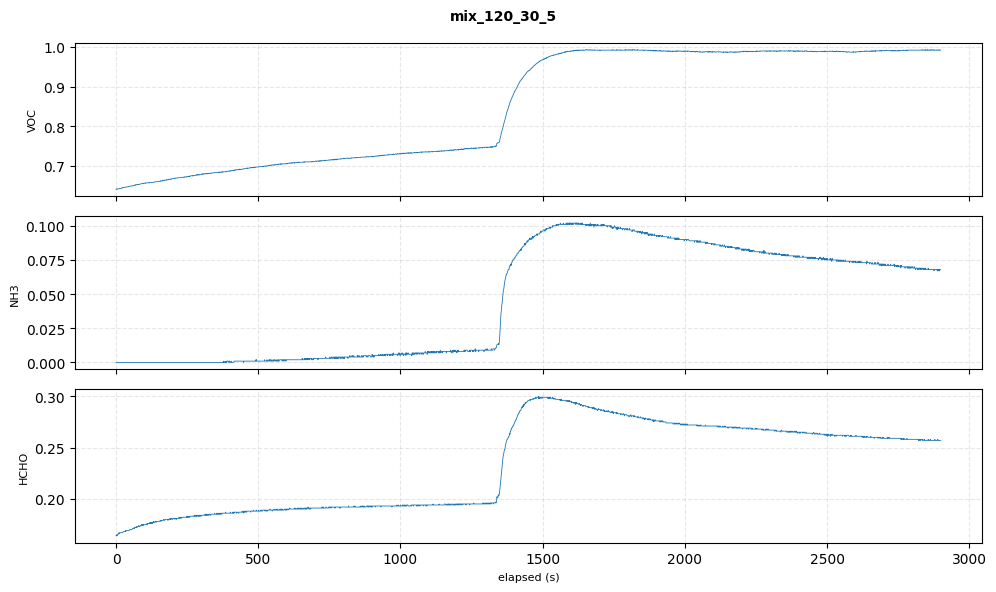

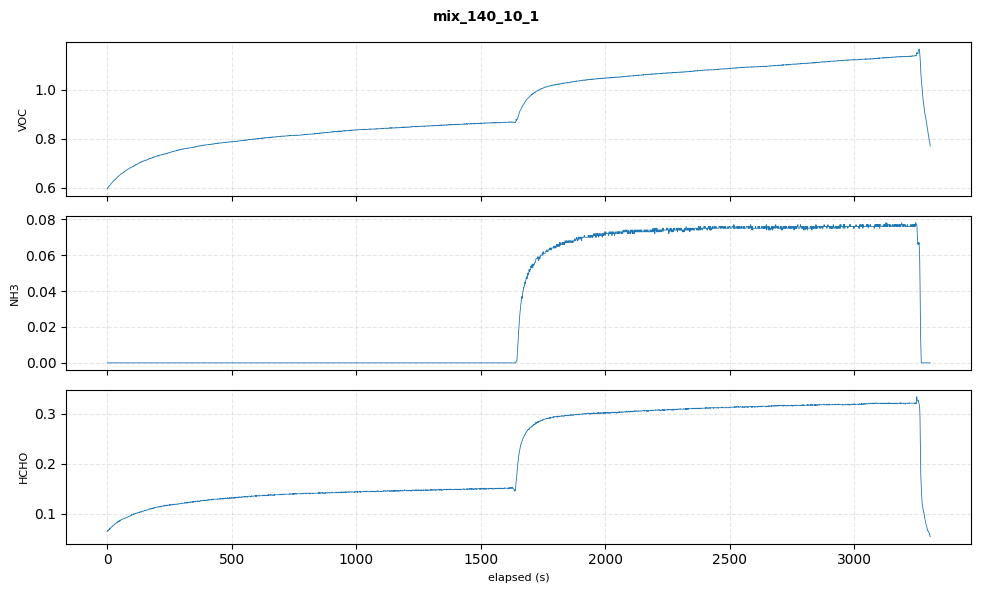

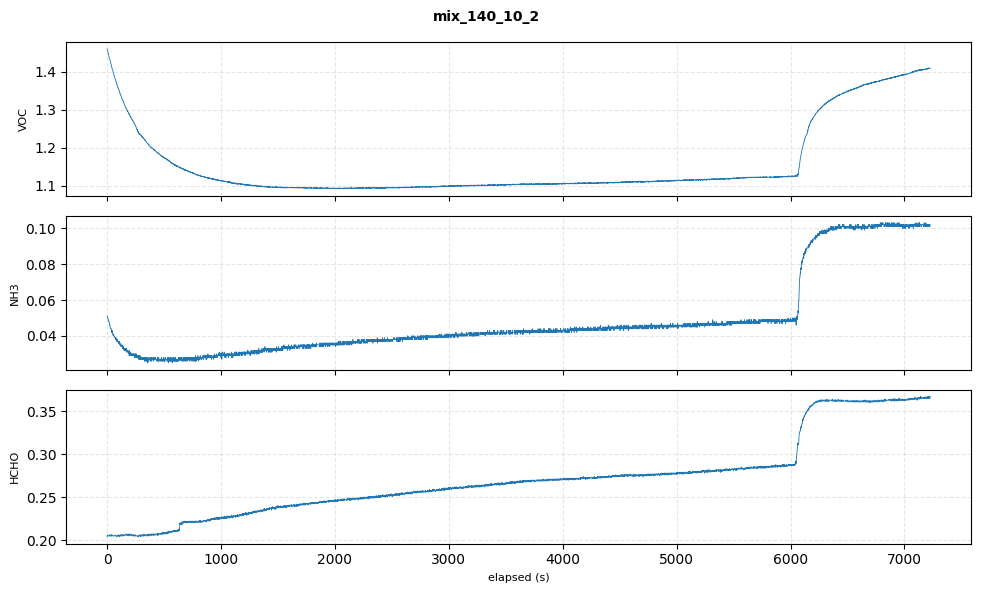

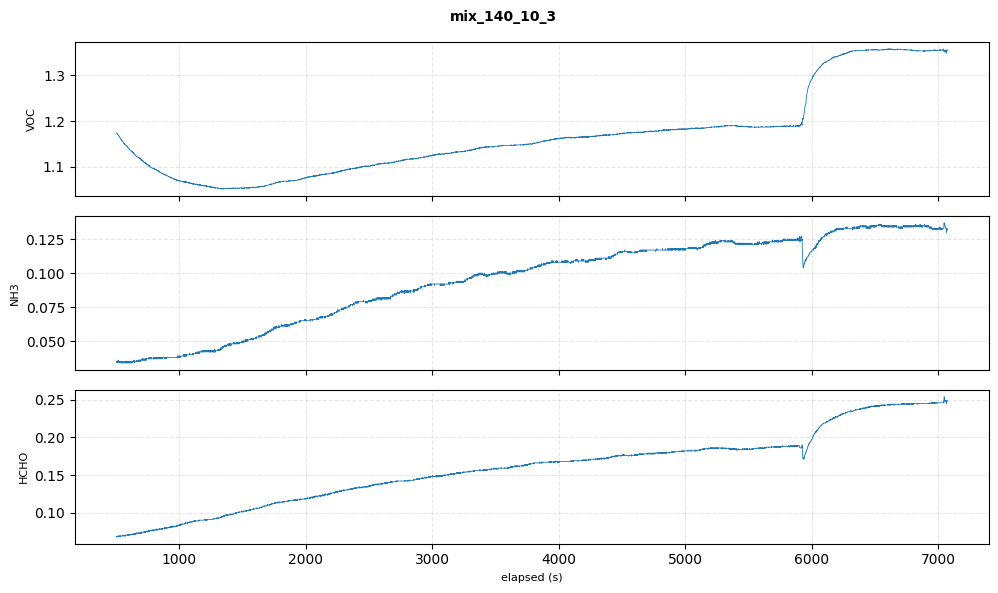

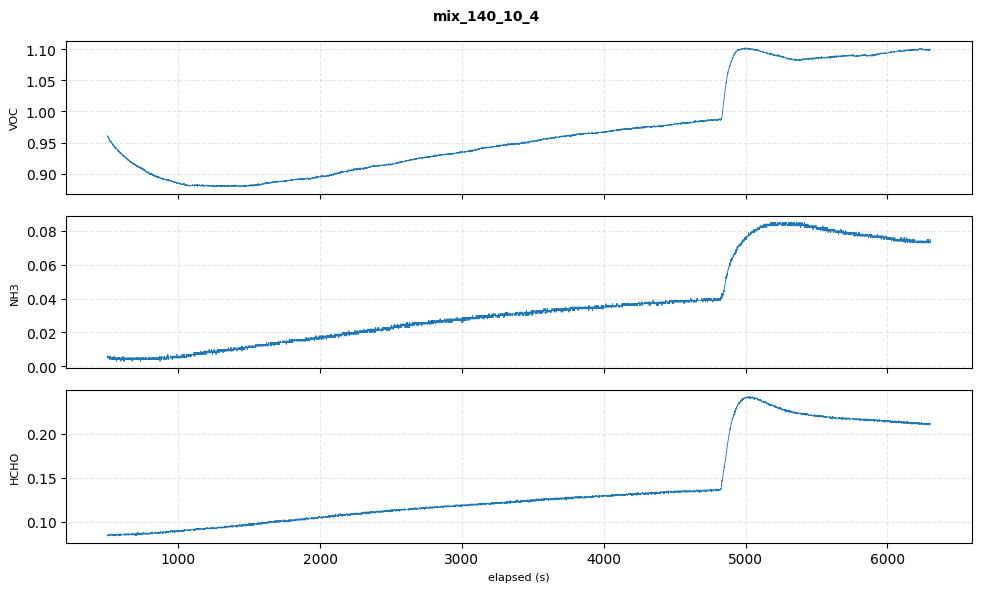

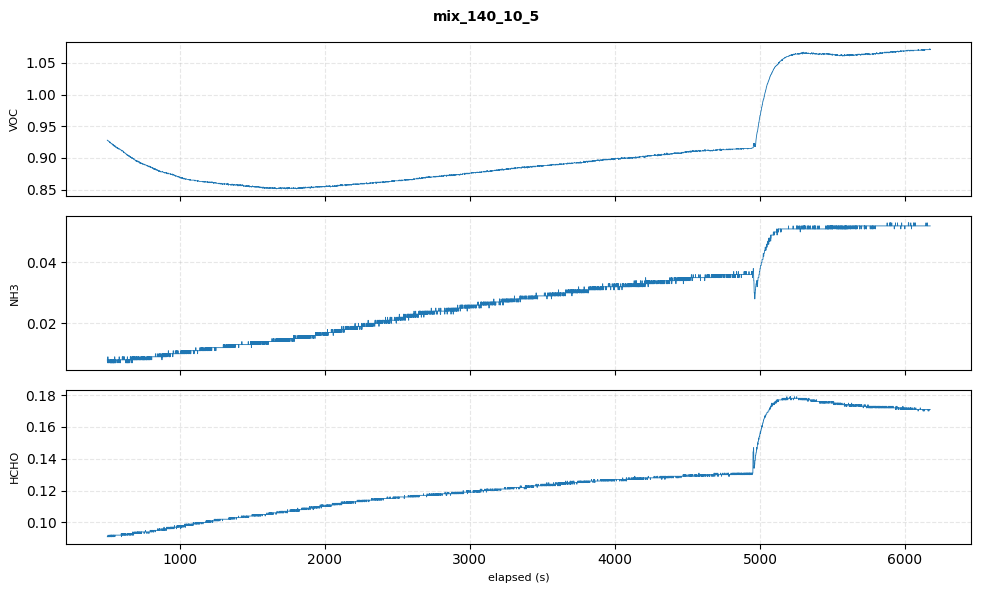

In [43]:
def plot_raw(name, df):
    fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    fig.suptitle(name, fontsize=10, fontweight="bold")
    for ax, col in zip(axes, MEMS):
        ax.plot(df["elapsed_s"], df[col], linewidth=0.6)
        ax.set_ylabel(col.upper(), fontsize=8)
        ax.grid(True, alpha=0.3, linestyle="--")
    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    plt.tight_layout()
    plt.show()

all_raw = [
    ("sweat_1a",     sweat_1a),    ("sweat_1b",     sweat_1b),
    ("sweat_2",      sweat_2),     ("sweat_3",      sweat_3),
    ("sweat_4",      sweat_4),     ("sweat_5",      sweat_5),
    ("sweat_6",      sweat_6),     ("sweat_7",      sweat_7),
    ("blood_0",      blood_0),     ("blood_1",      blood_1),
    ("blood_2",      blood_2),     ("blood_3",      blood_3),
    ("blood_4",      blood_4),     ("blood_5",      blood_5),
    ("blood_6",      blood_6),     ("blood_7",      blood_7),
    ("blood_8",      blood_8),     ("blood_9",      blood_9),
    ("mix_75_75_1",  mix_75_75_1), ("mix_75_75_2",  mix_75_75_2),
    ("mix_75_75_3",  mix_75_75_3), ("mix_75_75_4",  mix_75_75_4),
    ("mix_75_75_5",  mix_75_75_5),
    ("mix_120_30_1", mix_120_30_1),("mix_120_30_2", mix_120_30_2),
    ("mix_120_30_3", mix_120_30_3),("mix_120_30_4", mix_120_30_4),
    ("mix_120_30_5", mix_120_30_5),
    ("mix_140_10_1", mix_140_10_1),("mix_140_10_2", mix_140_10_2),
    ("mix_140_10_3", mix_140_10_3),("mix_140_10_4", mix_140_10_4),
    ("mix_140_10_5", mix_140_10_5),
]

for name, df in all_raw:
    if "mix" in name:
        plot_raw(name, df)

## Filter

Each MEMS channel (VOC, NH3, HCHO) passes through the following pipeline in order:

1. **Zero interpolation** — isolated zero-voltage samples (stuck ADC reads) are replaced with `NaN` and linearly interpolated. Enabled per-channel via `interpolate_cols`.

2. **Artifact patch** — known bad time windows are replaced with `NaN` and filled using **PCHIP** (Piecewise Cubic Hermite Interpolating Polynomial). PCHIP matches the slope at both edges of the gap and is monotonicity-preserving — it cannot overshoot or undershoot, unlike cubic spline. Specified per-channel via `artifact_windows: {col: [(t_start, t_end), ...]}`.

3. **Causal EMA smoothing** — exponential moving average with `span` (≈ seconds at 1 Hz). Uses `adjust=False` so it is fully causal (no future data). Per-channel span override available via `span_override`.

| Config key | Default | Description |
|---|---|---|
| `span` | 30 | EMA smoothing window (samples) |
| `span_override` | `{}` | Per-channel span override |
| `interpolate_cols` | `[]` | Channels to zero-interpolate |
| `artifact_windows` | `{}` | Manual bad-window patches per channel (PCHIP) |


In [44]:
FILTER_CONFIG = {
    "SWEAT_1a": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {
            "voc":  [(2950, 3100)],
            "nh3":  [(2950, 3100)],
            "hcho": [(2950, 3100)],
        },
    },
    "SWEAT_1b": {
        "span": 30,
        "span_override": {"nh3": 80},
        "interpolate_cols": [],
        "artifact_windows": {
            "hcho": [(540, 570)],
        },
    },
    "SWEAT_2": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "SWEAT_3": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {
            "nh3": [(3500, 3800)],
        },
    },
    "SWEAT_4": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "SWEAT_5": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {
            "nh3":  [(1050, 1300)],
            "hcho": [(1050, 1300)],
        },
    },
    "SWEAT_6": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "SWEAT_7": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {
            "nh3": [(1730, 1900)],
        },
    },
    "BLOOD_0": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": ["nh3"],
        "artifact_windows": {
            "nh3": [(1970, 2030)],
        },
    },
    "BLOOD_1": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "BLOOD_2": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "BLOOD_3": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {
            "nh3":  [(1975, 2010), (2575, 2680)],
            "hcho": [(2575, 2680)],
        },
    },
    "BLOOD_4": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "BLOOD_5": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "BLOOD_6": {
        "span": 60,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {
            "voc":  [(2760, 3060)],
            "hcho": [(2600, 2780)],
        },
    },
    "BLOOD_7": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "BLOOD_8": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "BLOOD_9": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {
            "nh3":  [(2300, 2430)],
            "hcho": [(2380, 2500)],
        },
    },
    # ── Mix samples ───────────────────────────────────────────────────────────
    "MIX_75_75_1": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {
            "nh3":  [(4300, 4600)],
            "hcho": [(4300, 4420)],
        },
    },
    "MIX_75_75_2": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "MIX_75_75_3": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "MIX_75_75_4": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "MIX_75_75_5": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "MIX_120_30_1": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {
            "hcho": [(1350, 1460)],
        },
    },
    "MIX_120_30_2": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "MIX_120_30_3": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "MIX_120_30_4": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "MIX_120_30_5": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "MIX_140_10_1": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "MIX_140_10_2": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "MIX_140_10_3": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {
            "voc":  [(5880, 6120)],
            "nh3":  [(5880, 6120)],
            "hcho": [(5880, 6120)],
        },
    },
    "MIX_140_10_4": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "MIX_140_10_5": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
}

def apply_filter(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    out = df.copy()

    for col in MEMS:
        s = out[col].copy().astype(float)

        # 1. Zero interpolation
        if col in config.get("interpolate_cols", []):
            s[s == 0.0] = float("nan")
            s = s.interpolate(method="linear").ffill().bfill()

        # 2. Artifact patch — PCHIP matches slope at edges without overshooting
        for t0, t1 in config.get("artifact_windows", {}).get(col, []):
            mask = (out["elapsed_s"] >= t0) & (out["elapsed_s"] <= t1)
            s[mask] = float("nan")
            s = s.interpolate(method="pchip").ffill().bfill()

        # 3. Causal EMA
        span: int = config.get("span_override", {}).get(col, config["span"])
        out[col] = s.ewm(span=span, adjust=False).mean()

    return out

filtered = {
    name: apply_filter(df, FILTER_CONFIG[name])
    for name, df in [
        ("SWEAT_1a",     sweat_1a),    ("SWEAT_1b",     sweat_1b),
        ("SWEAT_2",      sweat_2),     ("SWEAT_3",      sweat_3),
        ("SWEAT_4",      sweat_4),     ("SWEAT_5",      sweat_5),
        ("SWEAT_6",      sweat_6),     ("SWEAT_7",      sweat_7),
        ("BLOOD_0",      blood_0),     ("BLOOD_1",      blood_1),
        ("BLOOD_2",      blood_2),     ("BLOOD_3",      blood_3),
        ("BLOOD_4",      blood_4),     ("BLOOD_5",      blood_5),
        ("BLOOD_6",      blood_6),     ("BLOOD_7",      blood_7),
        ("BLOOD_8",      blood_8),     ("BLOOD_9",      blood_9),
        ("MIX_75_75_1",  mix_75_75_1), ("MIX_75_75_2",  mix_75_75_2),
        ("MIX_75_75_3",  mix_75_75_3), ("MIX_75_75_4",  mix_75_75_4),
        ("MIX_75_75_5",  mix_75_75_5),
        ("MIX_120_30_1", mix_120_30_1),("MIX_120_30_2", mix_120_30_2),
        ("MIX_120_30_3", mix_120_30_3),("MIX_120_30_4", mix_120_30_4),
        ("MIX_120_30_5", mix_120_30_5),
        ("MIX_140_10_1", mix_140_10_1),("MIX_140_10_2", mix_140_10_2),
        ("MIX_140_10_3", mix_140_10_3),("MIX_140_10_4", mix_140_10_4),
        ("MIX_140_10_5", mix_140_10_5),
    ]
}

print(f"Filtered {len(filtered)} datasets: {list(filtered.keys())}")

Filtered 33 datasets: ['SWEAT_1a', 'SWEAT_1b', 'SWEAT_2', 'SWEAT_3', 'SWEAT_4', 'SWEAT_5', 'SWEAT_6', 'SWEAT_7', 'BLOOD_0', 'BLOOD_1', 'BLOOD_2', 'BLOOD_3', 'BLOOD_4', 'BLOOD_5', 'BLOOD_6', 'BLOOD_7', 'BLOOD_8', 'BLOOD_9', 'MIX_75_75_1', 'MIX_75_75_2', 'MIX_75_75_3', 'MIX_75_75_4', 'MIX_75_75_5', 'MIX_120_30_1', 'MIX_120_30_2', 'MIX_120_30_3', 'MIX_120_30_4', 'MIX_120_30_5', 'MIX_140_10_1', 'MIX_140_10_2', 'MIX_140_10_3', 'MIX_140_10_4', 'MIX_140_10_5']


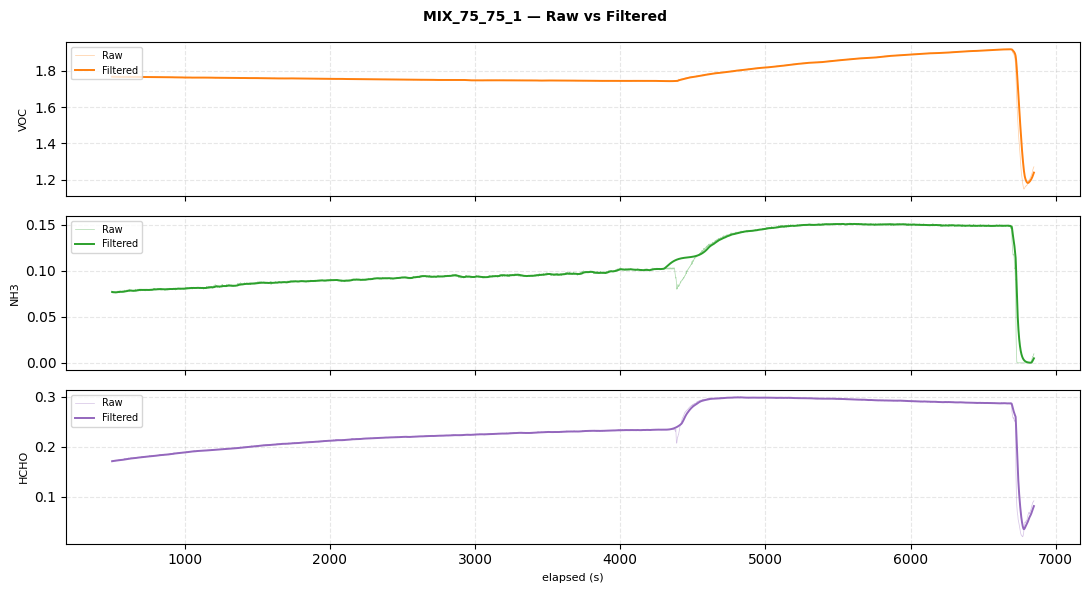

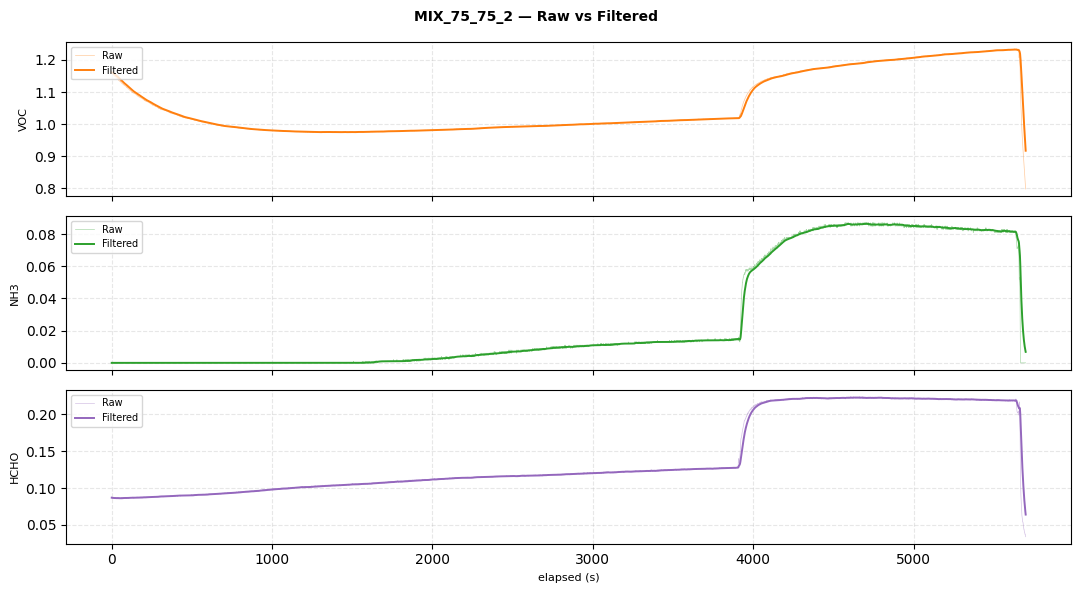

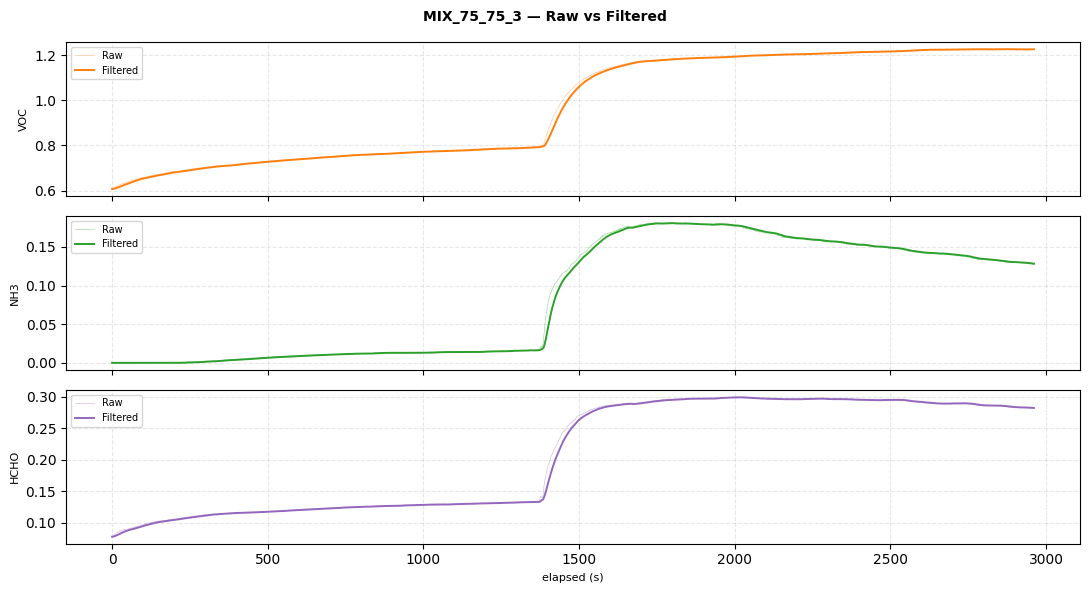

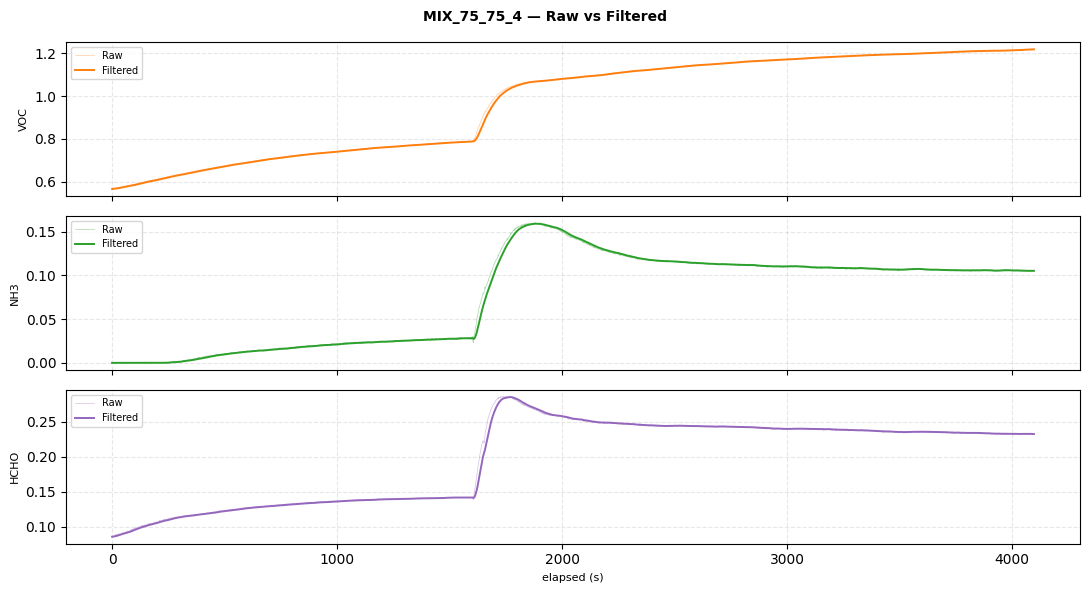

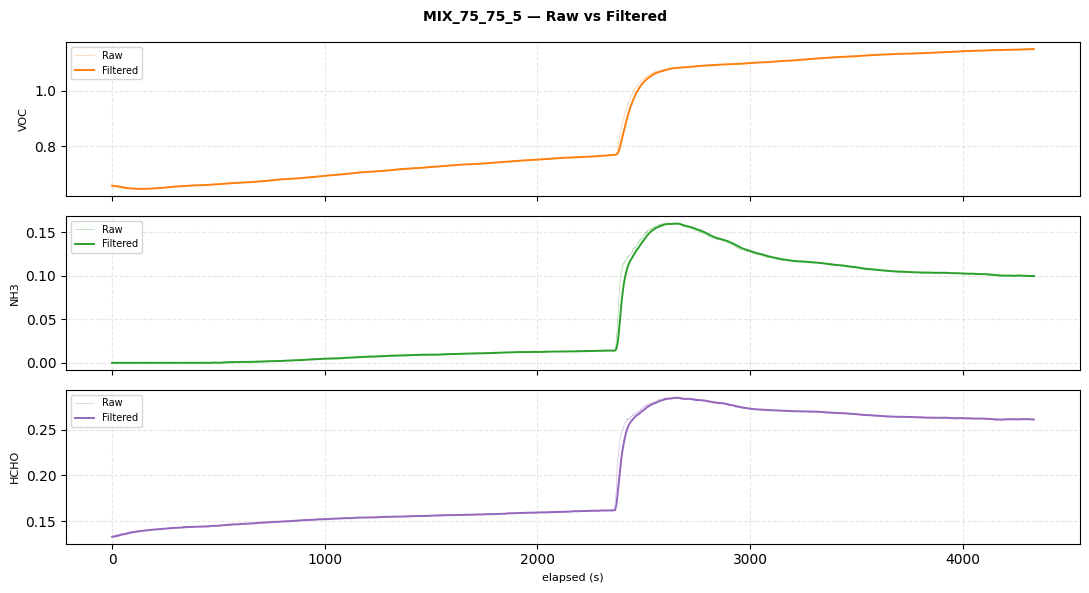

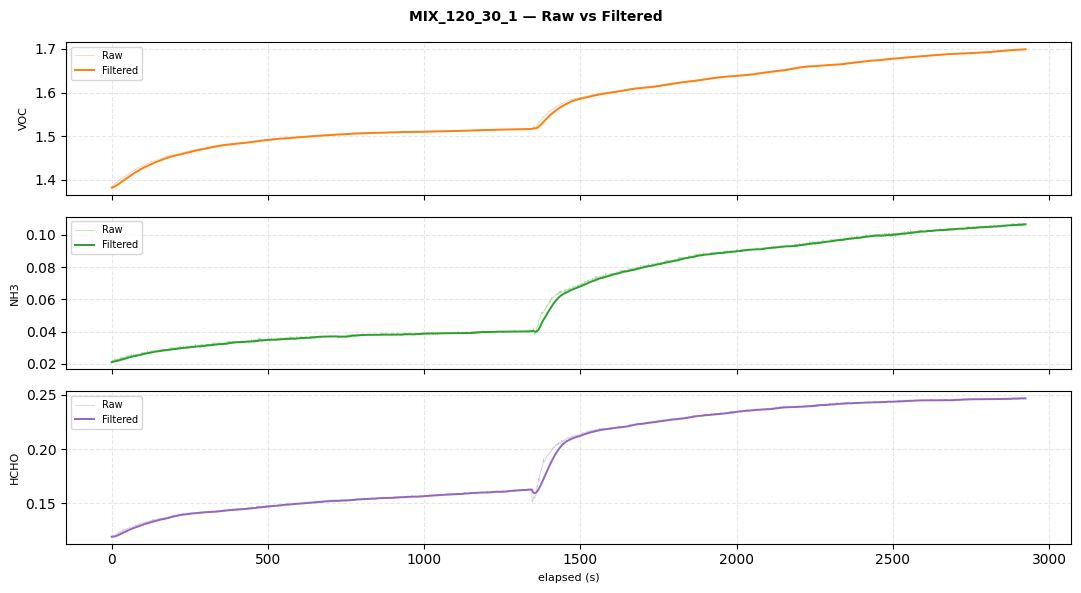

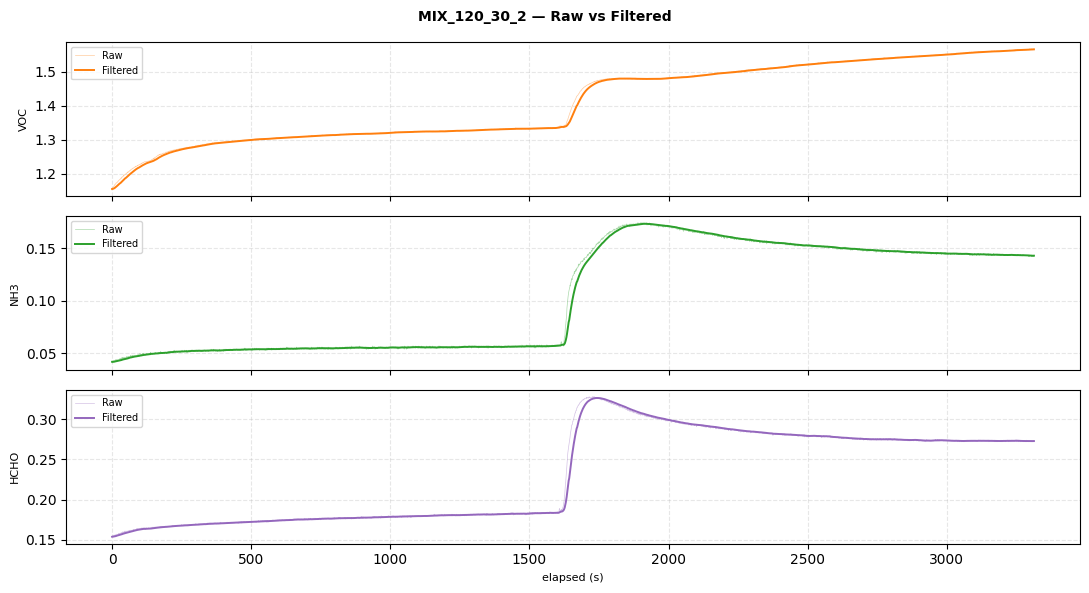

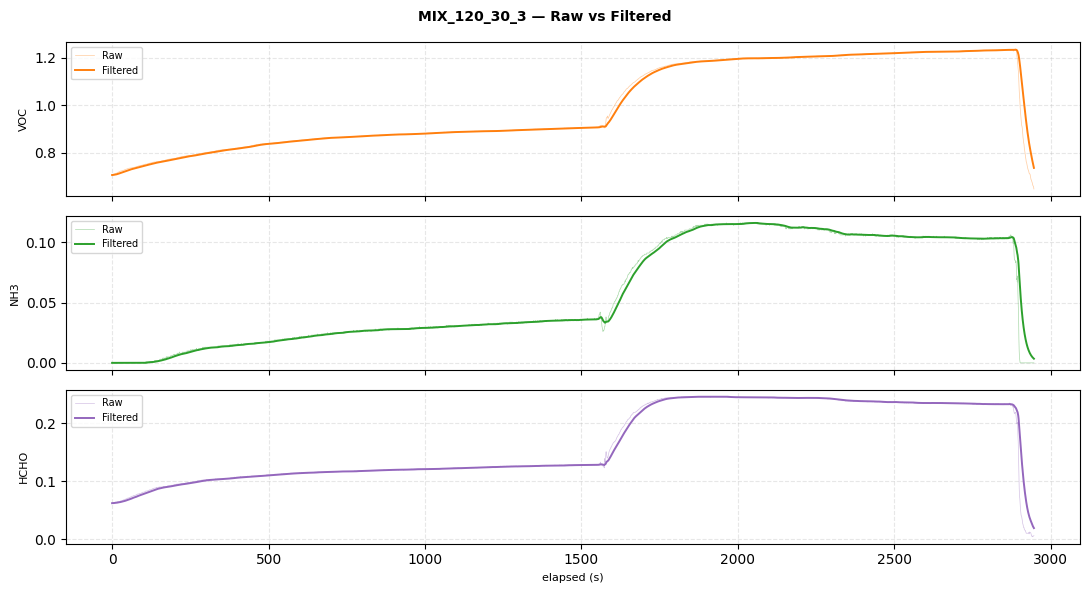

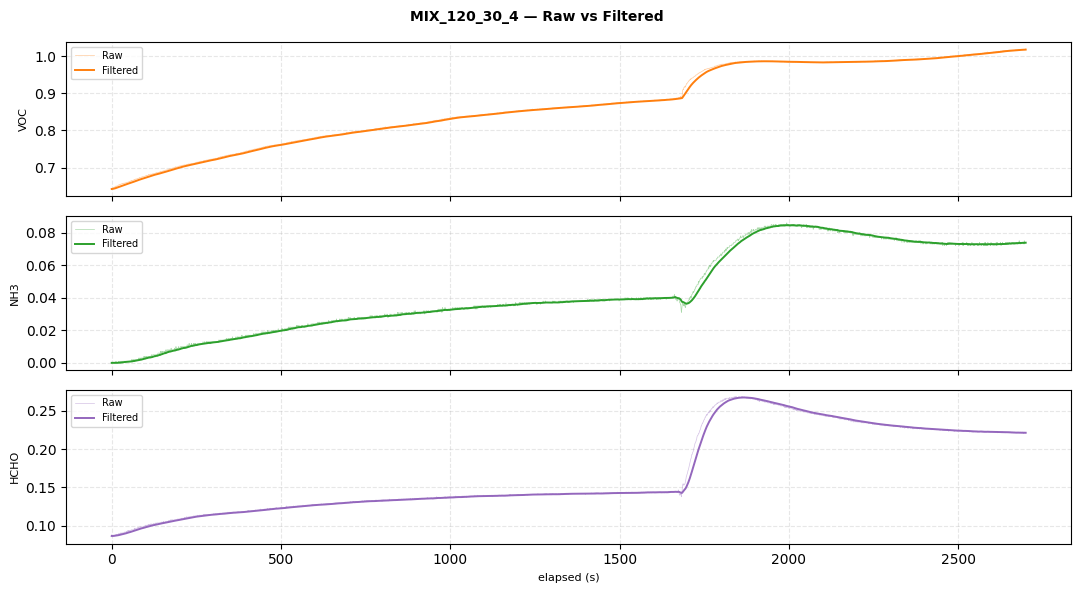

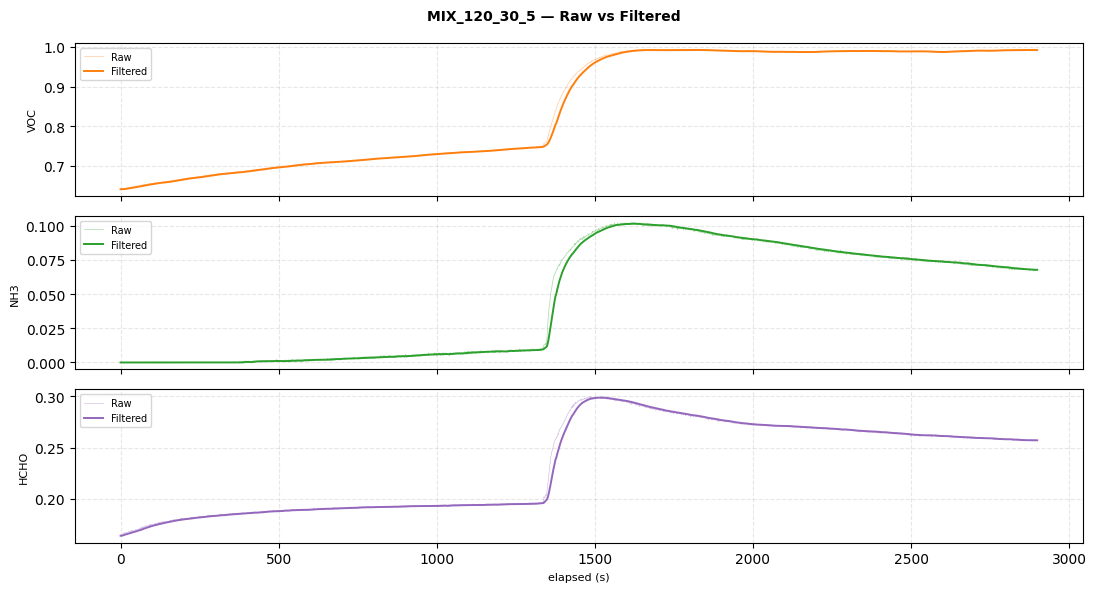

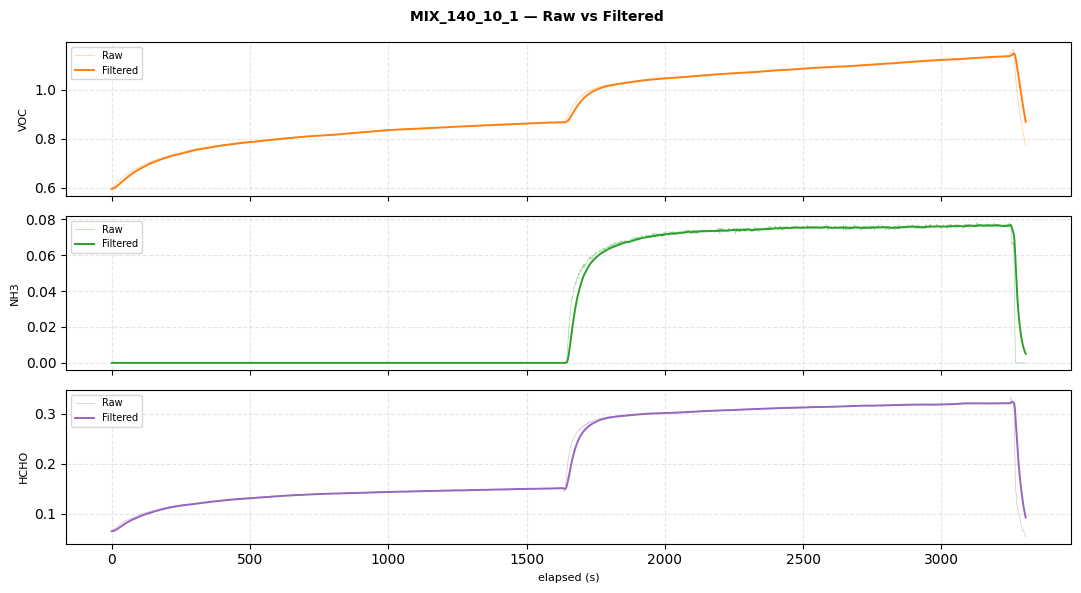

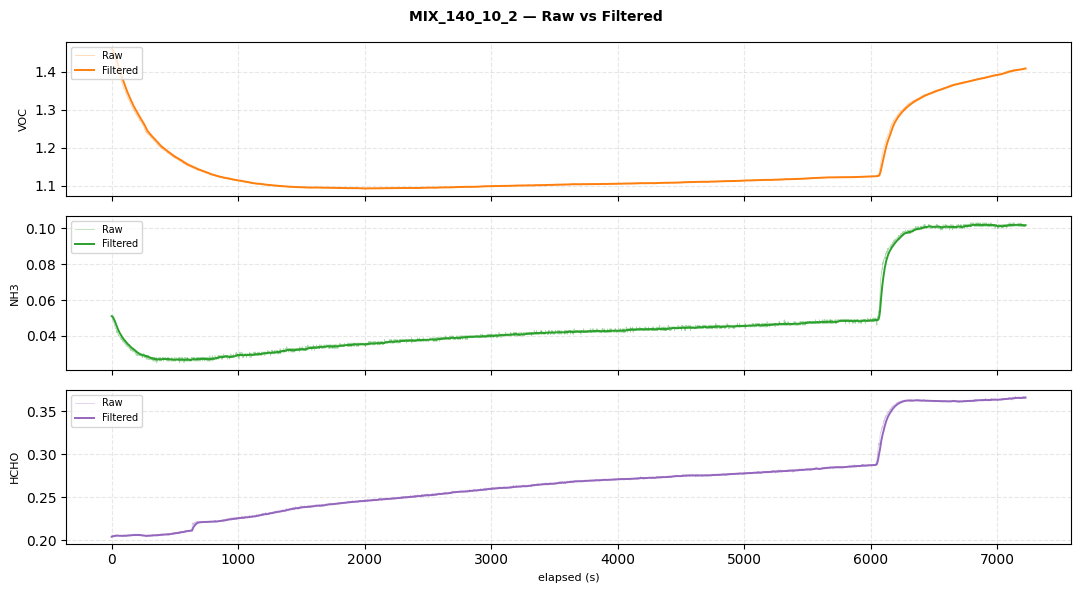

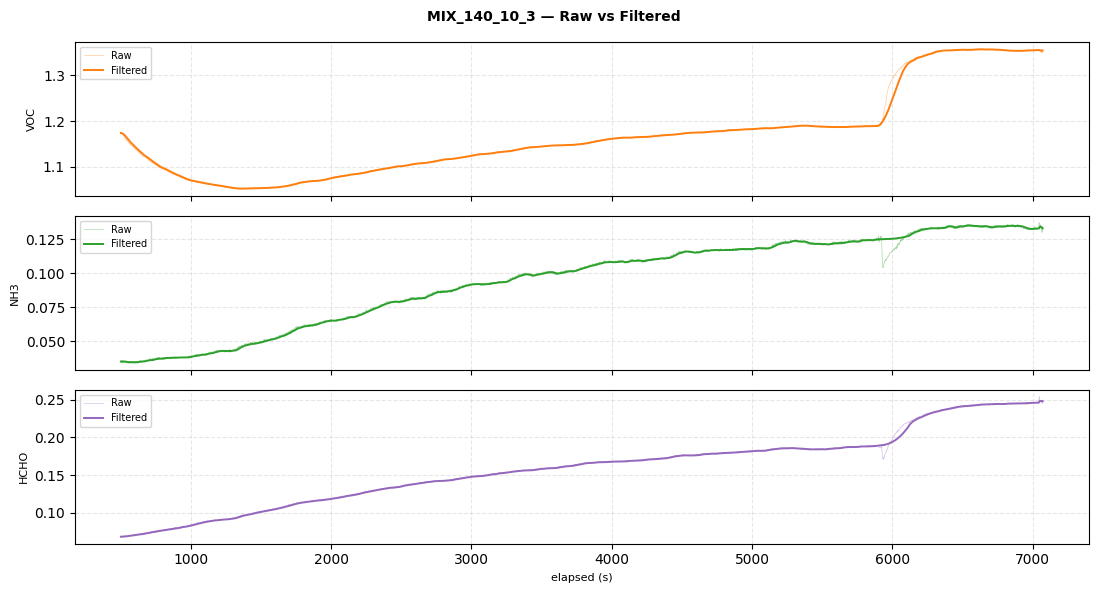

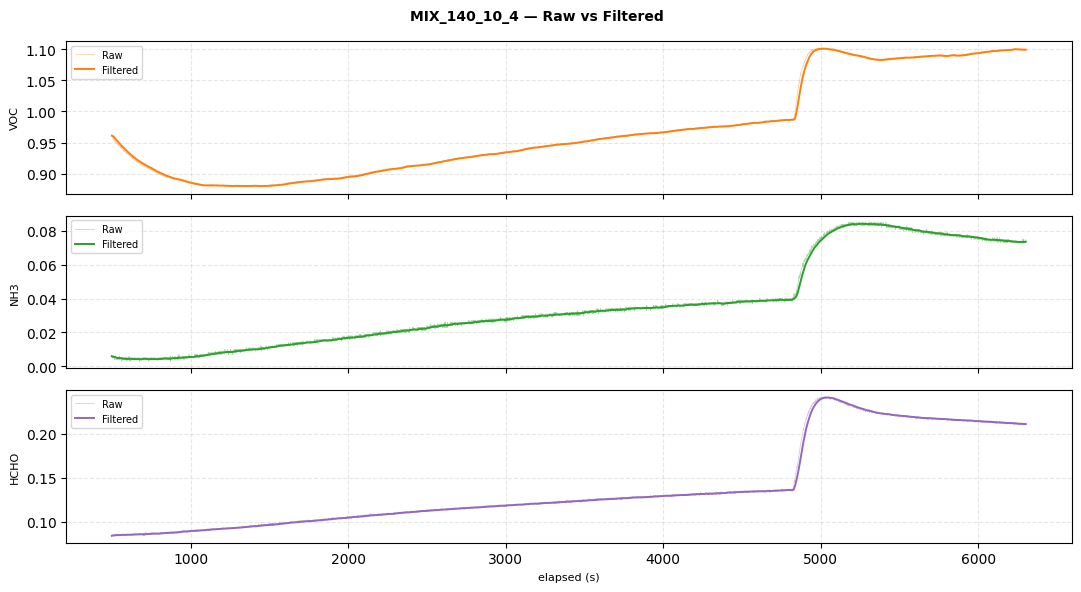

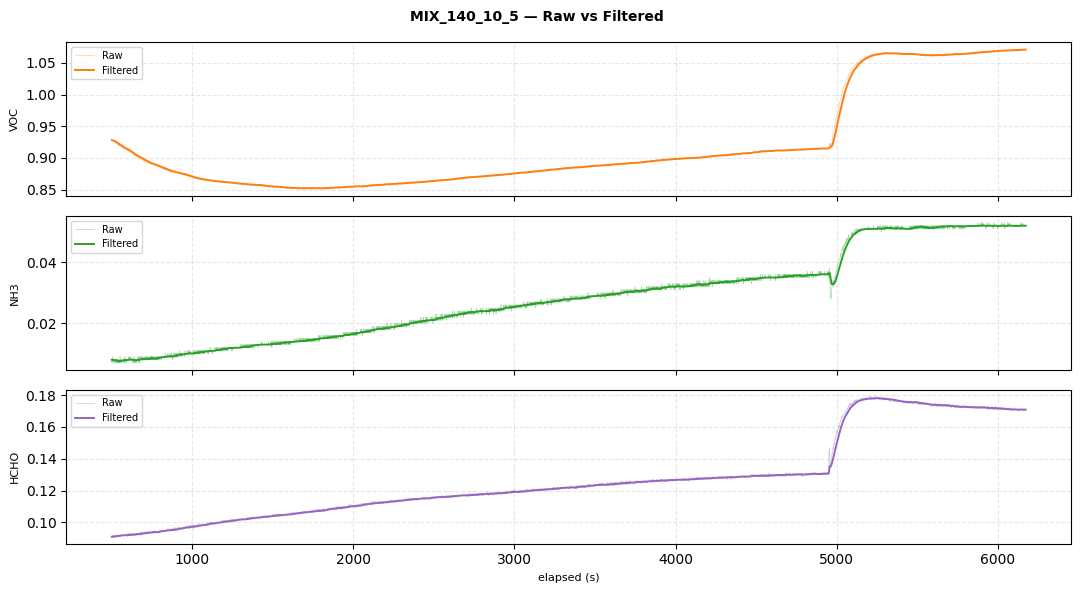

In [45]:
COLORS = {"voc": "tab:orange", "nh3": "tab:green", "hcho": "tab:purple"}

raw_map = {
    "SWEAT_1a":    sweat_1a,    "SWEAT_1b":    sweat_1b,
    "SWEAT_2":     sweat_2,     "SWEAT_3":     sweat_3,
    "SWEAT_4":     sweat_4,     "SWEAT_5":     sweat_5,
    "SWEAT_6":     sweat_6,     "SWEAT_7":     sweat_7,
    "BLOOD_0":     blood_0,     "BLOOD_1":     blood_1,
    "BLOOD_2":     blood_2,     "BLOOD_3":     blood_3,
    "BLOOD_4":     blood_4,     "BLOOD_5":     blood_5,
    "BLOOD_6":     blood_6,     "BLOOD_7":     blood_7,
    "BLOOD_8":     blood_8,     "BLOOD_9":     blood_9,
    "MIX_75_75_1":  mix_75_75_1, "MIX_75_75_2":  mix_75_75_2,
    "MIX_75_75_3":  mix_75_75_3, "MIX_75_75_4":  mix_75_75_4,
    "MIX_75_75_5":  mix_75_75_5,
    "MIX_120_30_1": mix_120_30_1,"MIX_120_30_2": mix_120_30_2,
    "MIX_120_30_3": mix_120_30_3,"MIX_120_30_4": mix_120_30_4,
    "MIX_120_30_5": mix_120_30_5,
    "MIX_140_10_1": mix_140_10_1,"MIX_140_10_2": mix_140_10_2,
    "MIX_140_10_3": mix_140_10_3,"MIX_140_10_4": mix_140_10_4,
    "MIX_140_10_5": mix_140_10_5,
}

for name, filt_df in filtered.items():
    if "MIX" not in name:
        continue
    raw_df = raw_map[name]
    fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
    fig.suptitle(f"{name} — Raw vs Filtered", fontsize=10, fontweight="bold")

    for ax, col in zip(axes, MEMS):
        color = COLORS[col]
        ax.plot(raw_df["elapsed_s"],  raw_df[col],  color=color, linewidth=0.5, alpha=0.4, label="Raw")
        ax.plot(filt_df["elapsed_s"], filt_df[col], color=color, linewidth=1.4, label="Filtered")
        ax.set_ylabel(col.upper(), fontsize=8)
        ax.legend(fontsize=7, loc="upper left")
        ax.grid(True, alpha=0.3, linestyle="--")

    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    plt.tight_layout()
    plt.show()

## Baseline and Sensor Drift Correction

Fits a linear trend to the pre-sample window of each channel and subtracts it from the full signal. Corrects for both the session baseline offset and slow in-session drift.

```
corrected(t) = filtered(t) − (a·t + b),   clipped at 0
```


Dataset            Baseline window  channel      slope (V/s)   intercept (V)
--------------------------------------------------------------------------------
SWEAT_1a                1500–2800s  voc            -0.000036          0.9241
SWEAT_1a                1500–2800s  nh3            -0.000000          0.0000
SWEAT_1a                1500–2800s  hcho            0.000016          0.0218
SWEAT_1b                    0–570s  voc             0.000104          0.8080
SWEAT_1b                    0–570s  nh3             0.000000         -0.0000
SWEAT_1b                    0–570s  hcho            0.000052          0.0500
SWEAT_2                 3000–4000s  voc             0.000014          1.3746
SWEAT_2                 3000–4000s  nh3             0.000007          0.0059
SWEAT_2                 3000–4000s  hcho            0.000011          0.2139
SWEAT_3                 2500–3500s  voc             0.000003          1.5014
SWEAT_3                 2500–3500s  nh3             0.000003          0.

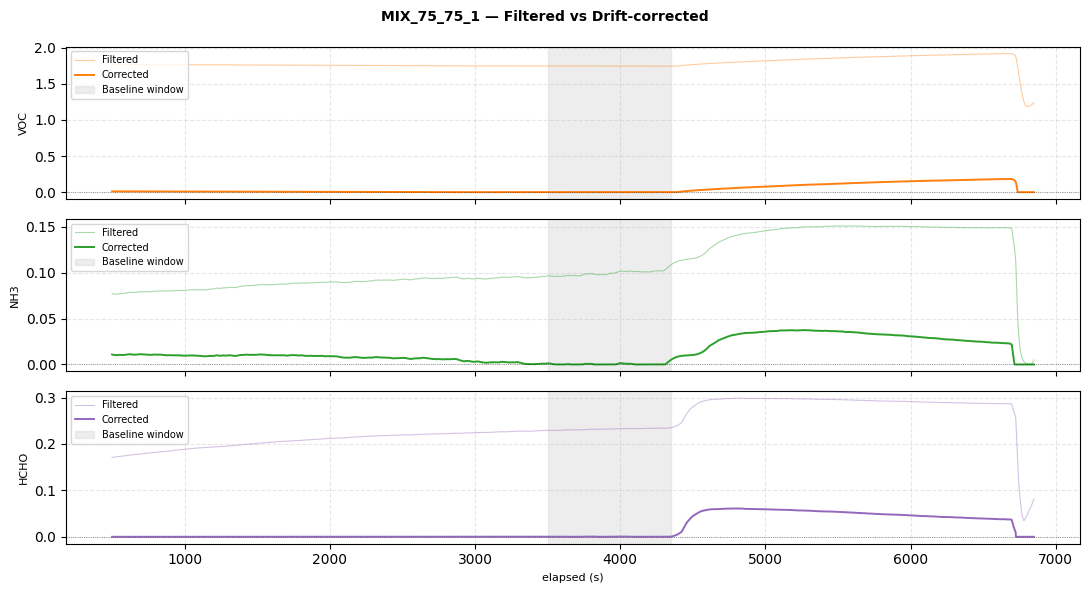

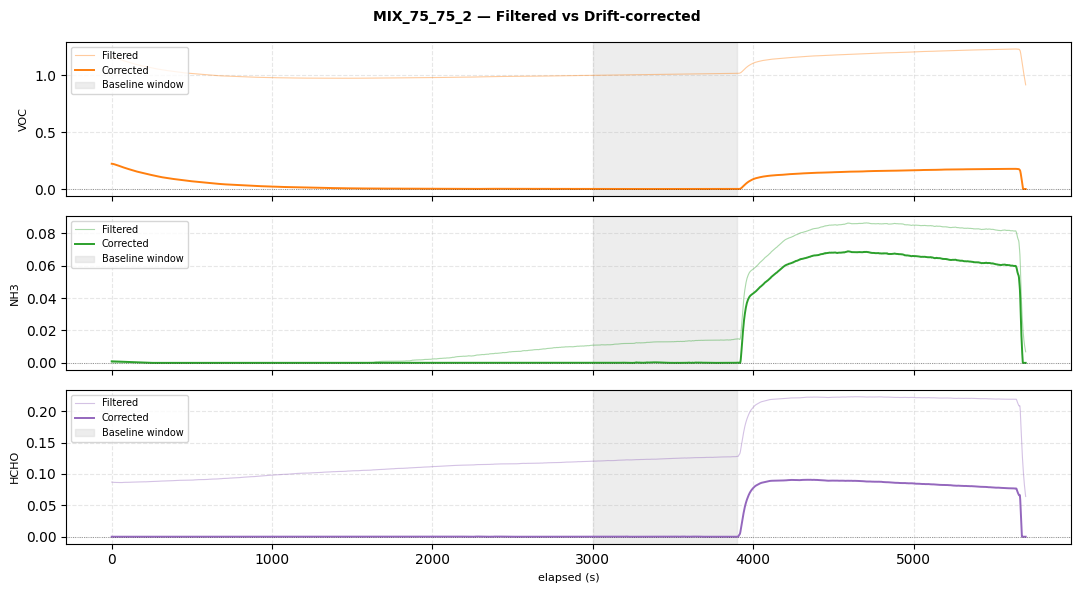

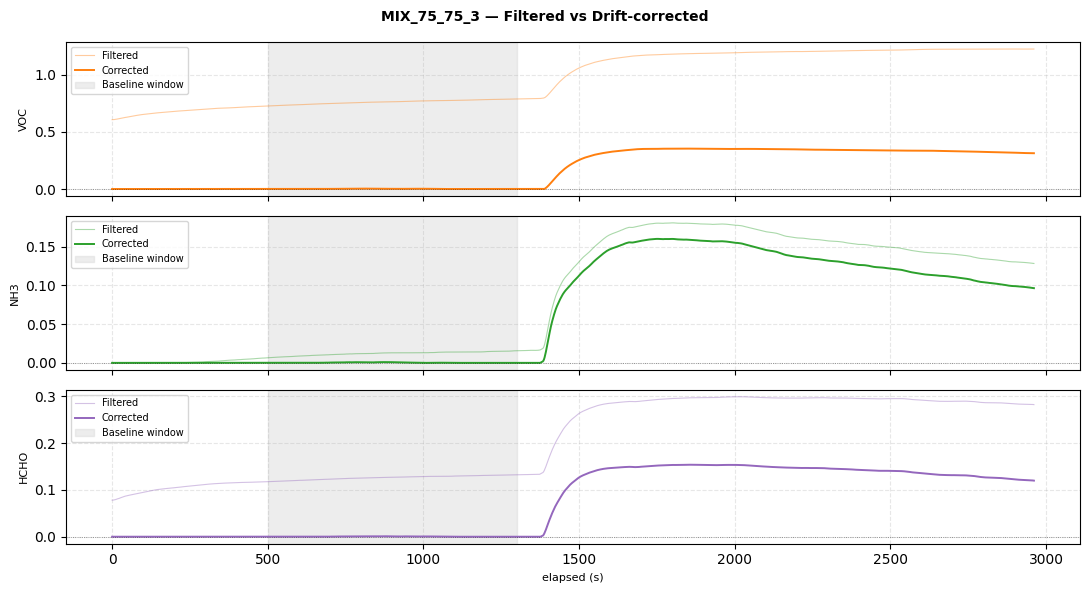

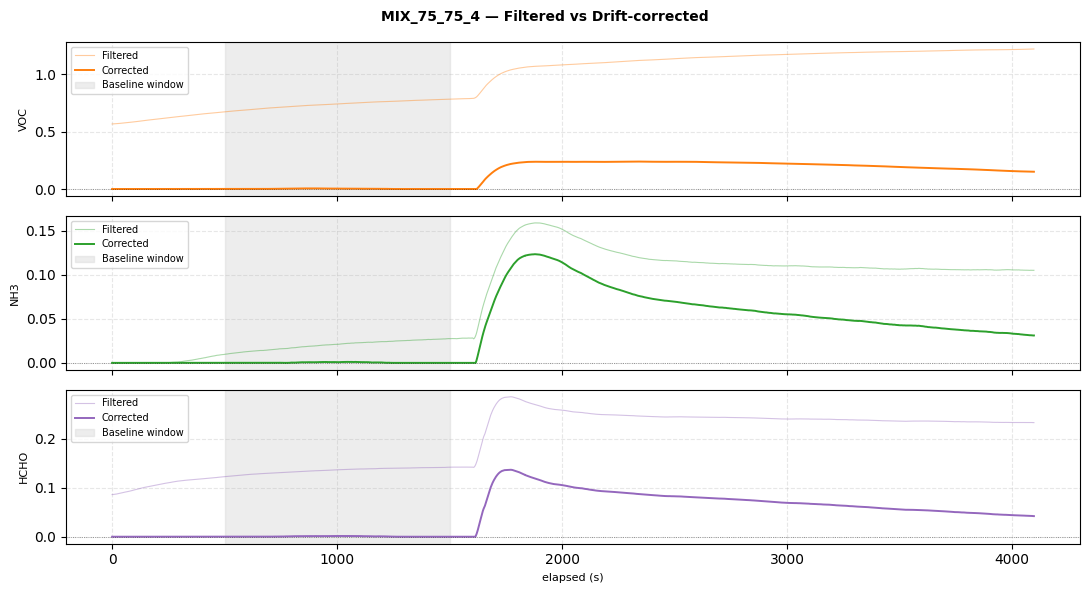

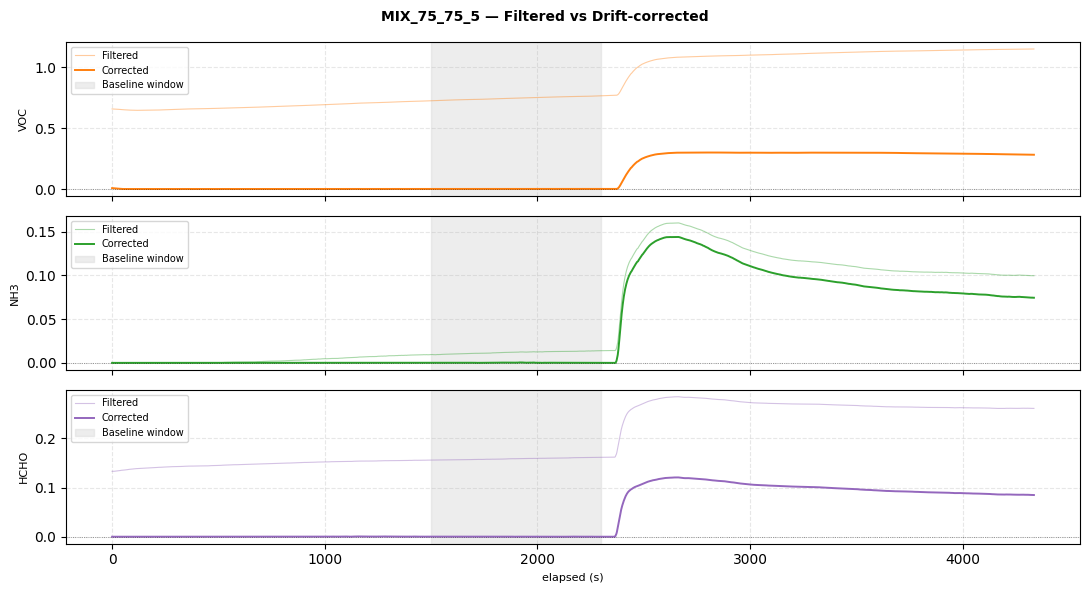

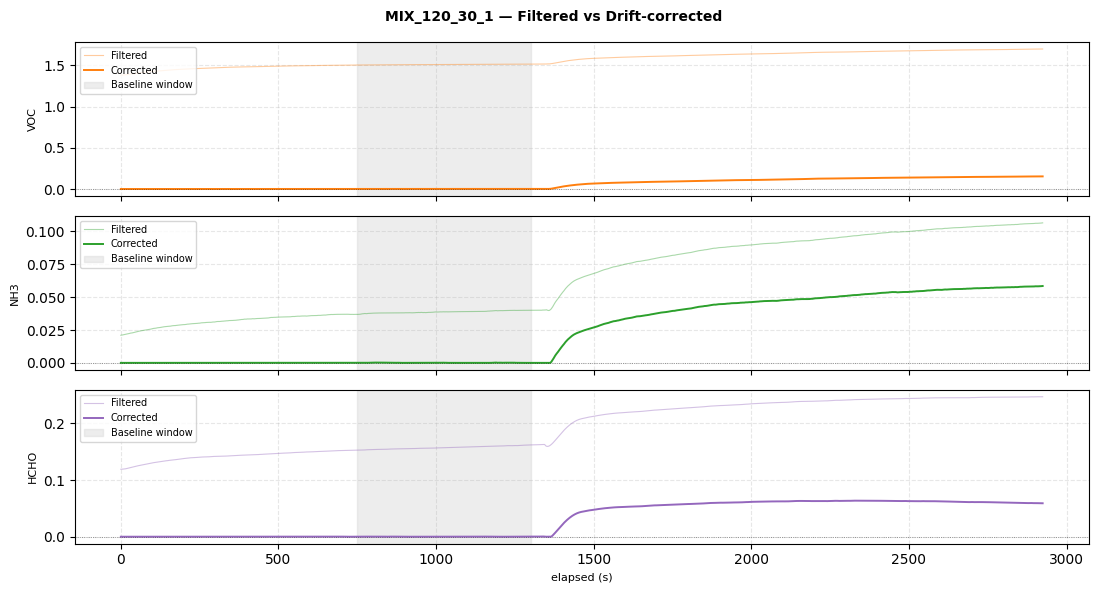

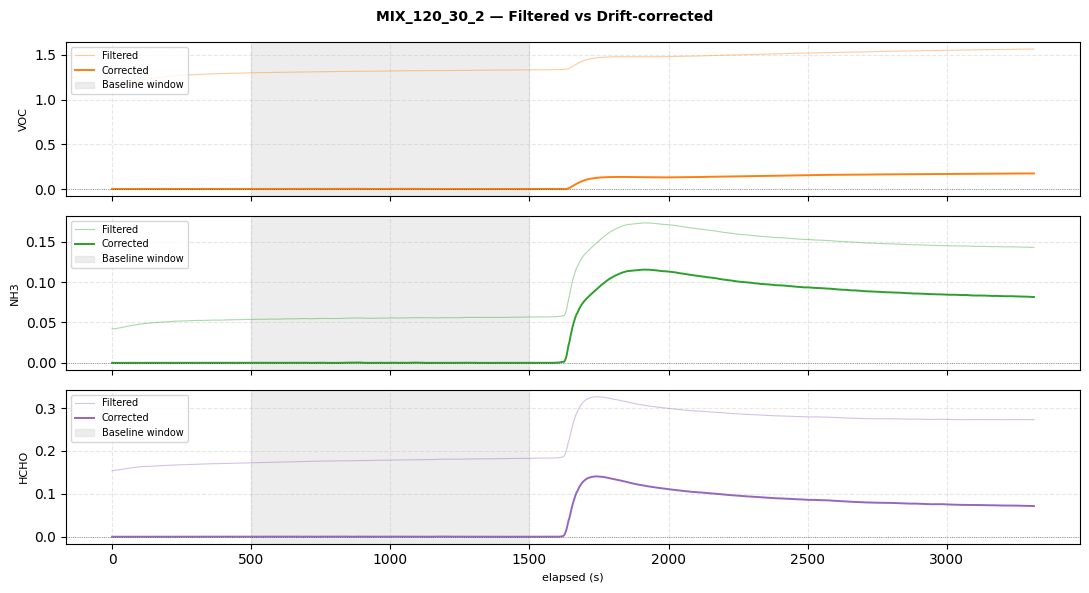

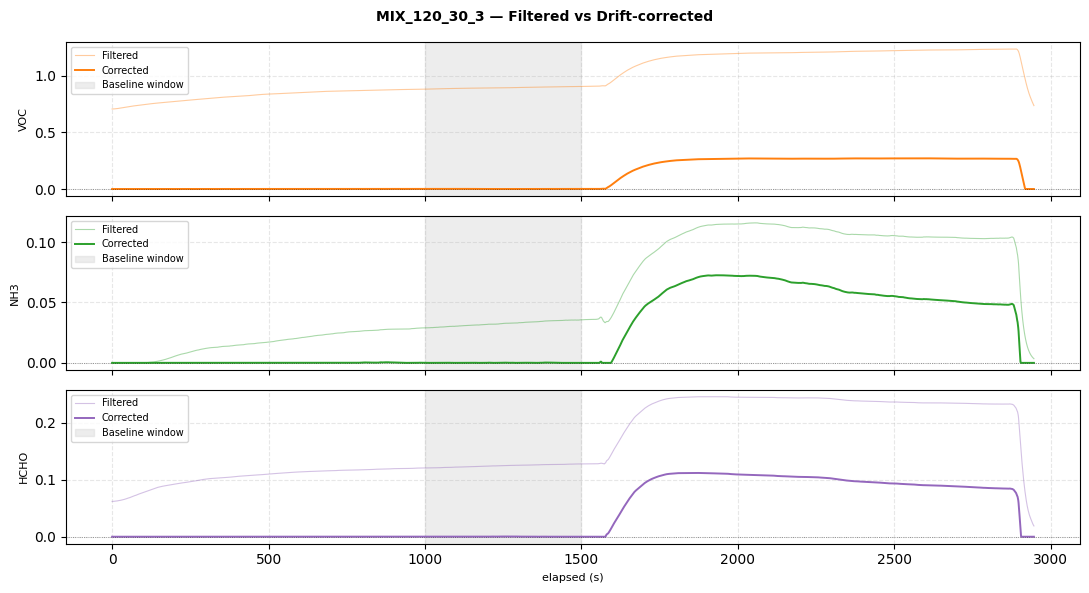

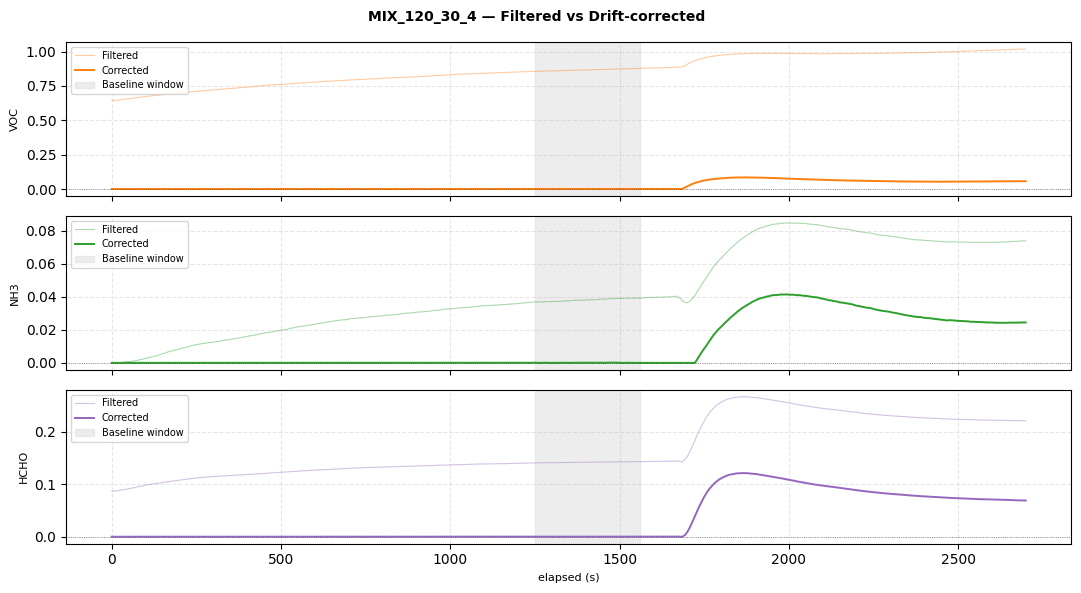

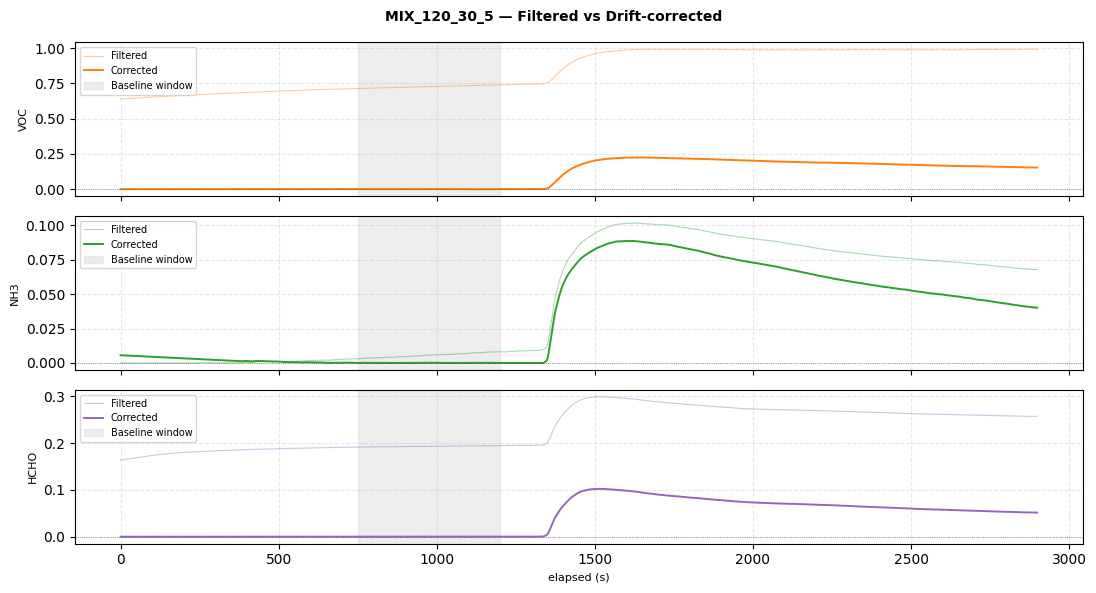

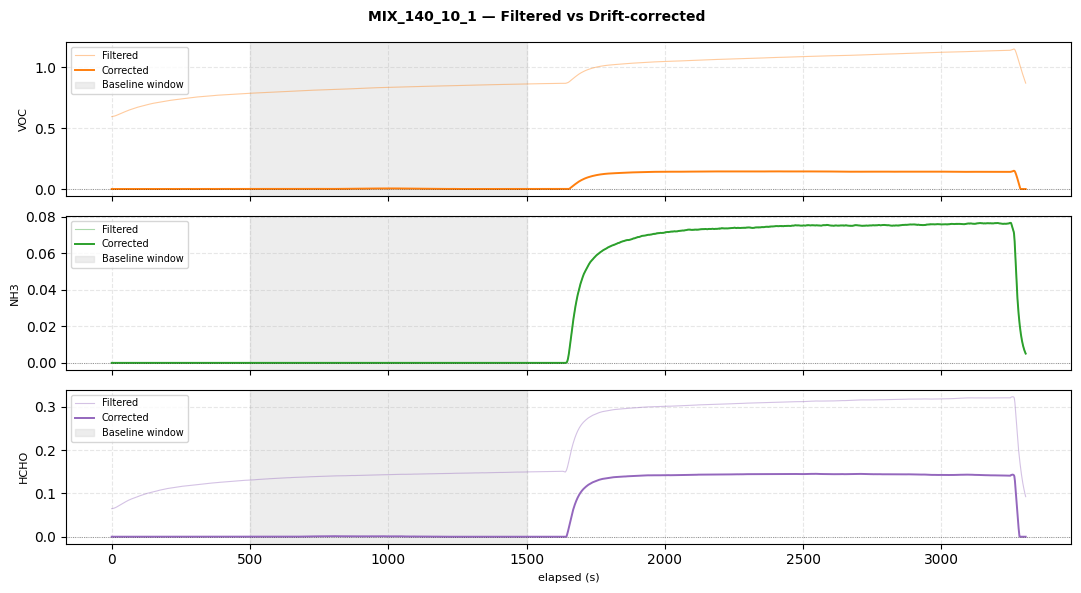

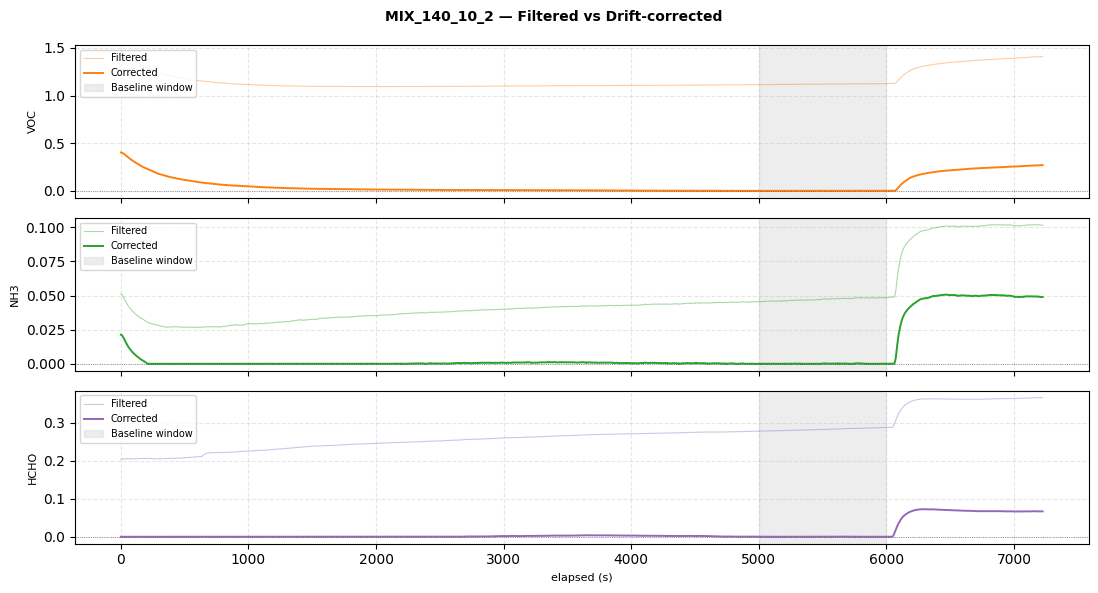

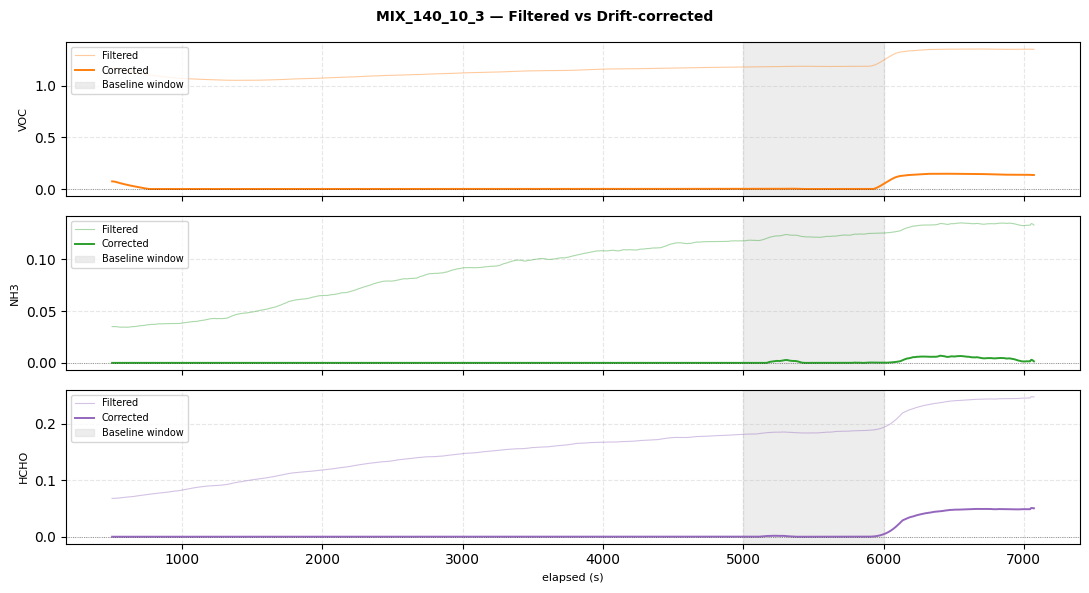

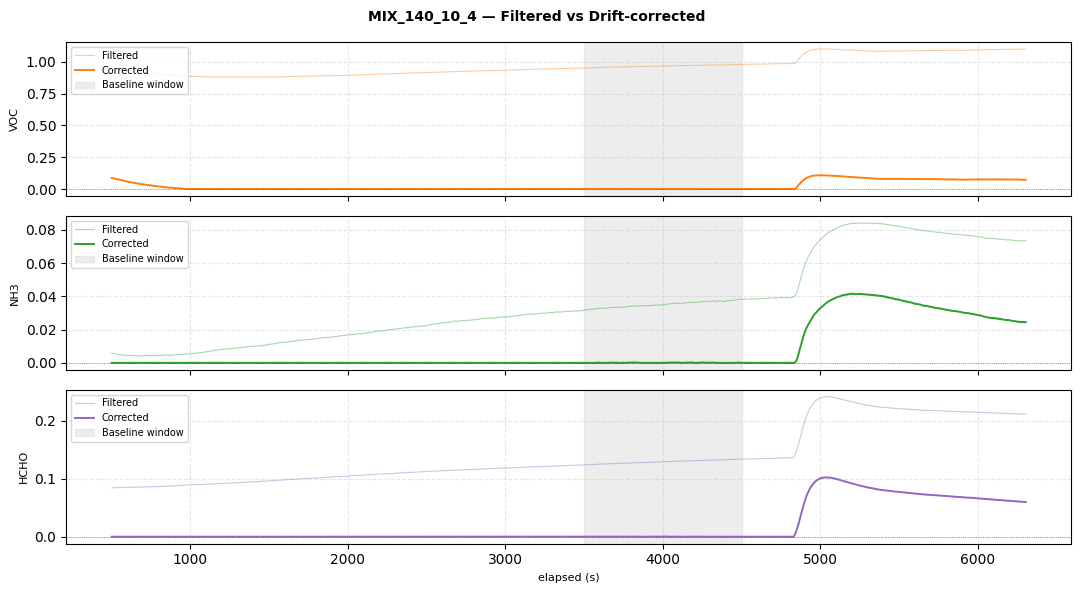

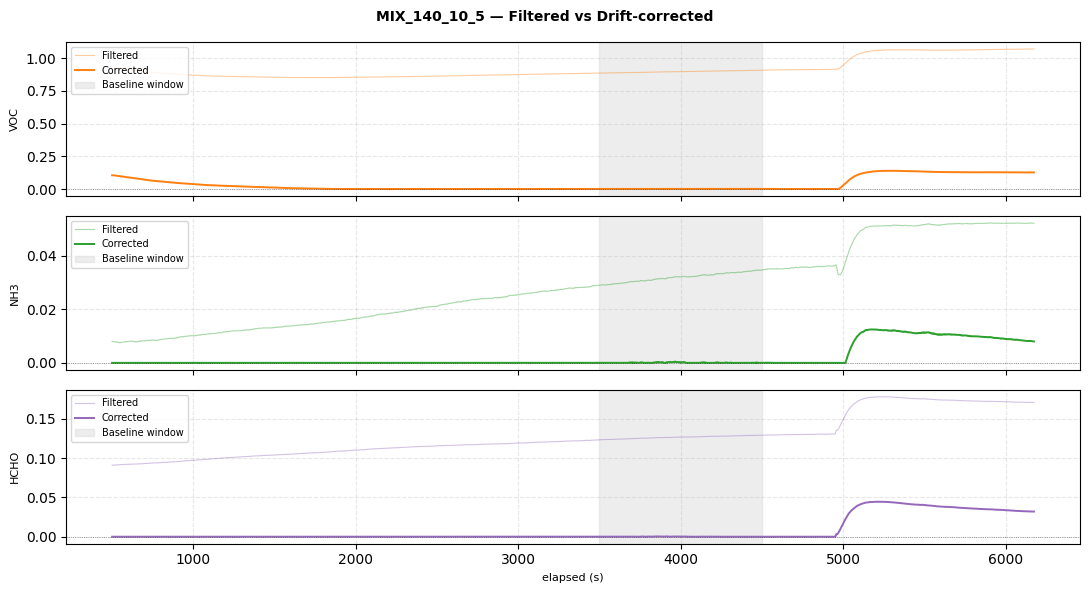

In [46]:
import numpy as np

# Pre-sample baseline windows (elapsed_s) — stable period before sample introduction.
# Verify windows marked [est] against raw plots; the others are confirmed from visual inspection.
BASELINE_WINDOWS = {
    "SWEAT_1a": (1500, 2800),
    "SWEAT_1b": (0,    570),
    "SWEAT_2":  (3000, 4000),
    "SWEAT_3":  (2500, 3500),
    "SWEAT_4":  (2500, 3500),
    "SWEAT_5":  (500,  1000),
    "SWEAT_6":  (4000, 4500),
    "SWEAT_7":  (1000, 1500),
    "BLOOD_0":  (1000, 1750),
    "BLOOD_1":  (1750, 2440),
    "BLOOD_2":  (1000, 1500),
    "BLOOD_3":  (1000, 1800),
    "BLOOD_4":  (1000, 1200),
    "BLOOD_5":  (1000, 1500),
    "BLOOD_6":  (1500, 2200),
    "BLOOD_7":  (1500, 2000),
    "BLOOD_8":  (1500, 2200),
    "BLOOD_9":  (1000, 2000),
    # ── Mix samples ───────────────────────────────────────────────────────────
    "MIX_75_75_1":  (3500, 4350),  
    "MIX_75_75_2":  (3000, 3900),  
    "MIX_75_75_3":  (500,  1300),  
    "MIX_75_75_4":  (500,  1500),  
    "MIX_75_75_5":  (1500, 2300),  
    "MIX_120_30_1": (750,  1300),  
    "MIX_120_30_2": (500,  1500),  
    "MIX_120_30_3": (1000, 1500),  
    "MIX_120_30_4": (1250, 1560),  
    "MIX_120_30_5": (750,  1200),  
    "MIX_140_10_1": (500,  1500),  
    "MIX_140_10_2": (5000, 6000),  
    "MIX_140_10_3": (5000, 6000),  
    "MIX_140_10_4": (3500, 4500),  
    "MIX_140_10_5": (3500, 4500),  
}

ALL_SESSIONS = [
    ("SWEAT_1a",     sweat_1a),    ("SWEAT_1b",     sweat_1b),
    ("SWEAT_2",      sweat_2),     ("SWEAT_3",      sweat_3),
    ("SWEAT_4",      sweat_4),     ("SWEAT_5",      sweat_5),
    ("SWEAT_6",      sweat_6),     ("SWEAT_7",      sweat_7),
    ("BLOOD_0",      blood_0),     ("BLOOD_1",      blood_1),
    ("BLOOD_2",      blood_2),     ("BLOOD_3",      blood_3),
    ("BLOOD_4",      blood_4),     ("BLOOD_5",      blood_5),
    ("BLOOD_6",      blood_6),     ("BLOOD_7",      blood_7),
    ("BLOOD_8",      blood_8),     ("BLOOD_9",      blood_9),
    ("MIX_75_75_1",  mix_75_75_1), ("MIX_75_75_2",  mix_75_75_2),
    ("MIX_75_75_3",  mix_75_75_3), ("MIX_75_75_4",  mix_75_75_4),
    ("MIX_75_75_5",  mix_75_75_5),
    ("MIX_120_30_1", mix_120_30_1),("MIX_120_30_2", mix_120_30_2),
    ("MIX_120_30_3", mix_120_30_3),("MIX_120_30_4", mix_120_30_4),
    ("MIX_120_30_5", mix_120_30_5),
    ("MIX_140_10_1", mix_140_10_1),("MIX_140_10_2", mix_140_10_2),
    ("MIX_140_10_3", mix_140_10_3),("MIX_140_10_4", mix_140_10_4),
    ("MIX_140_10_5", mix_140_10_5),
]

corrected = {}

print(f"{'Dataset':<14}  {'Baseline window':>18}  {'channel':<8}  {'slope (V/s)':>14}  {'intercept (V)':>14}")
print("-" * 80)

for name, df in ALL_SESSIONS:
    filt_df   = filtered[name].copy()
    t0, t1    = BASELINE_WINDOWS[name]
    base_mask = (filt_df["elapsed_s"] >= t0) & (filt_df["elapsed_s"] <= t1)
    t_all     = filt_df["elapsed_s"].values

    for col in MEMS:
        t_base = filt_df.loc[base_mask, "elapsed_s"].values
        s_base = filt_df.loc[base_mask, col].values
        a, b   = np.polyfit(t_base, s_base, deg=1)
        trend  = a * t_all + b
        filt_df[col] = (filt_df[col] - trend).clip(lower=0)
        print(f"{name:<14}  {f'{t0}–{t1}s':>18}  {col:<8}  {a:>14.6f}  {b:>14.4f}")

    corrected[name] = filt_df

# ── Visualize corrected vs filtered (mix only) ────────────────────────────────
for name, _ in ALL_SESSIONS:
    if "MIX" not in name:
        continue
    raw_filt = filtered[name]
    corr     = corrected[name]
    t0, t1   = BASELINE_WINDOWS[name]

    fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
    fig.suptitle(f"{name} — Filtered vs Drift-corrected", fontsize=10, fontweight="bold")

    for ax, col in zip(axes, MEMS):
        color = COLORS[col]
        ax.plot(raw_filt["elapsed_s"], raw_filt[col], color=color,
                linewidth=0.8, alpha=0.4, label="Filtered")
        ax.plot(corr["elapsed_s"],     corr[col],     color=color,
                linewidth=1.4, label="Corrected")
        ax.axvspan(t0, t1, color="lightgrey", alpha=0.4, label="Baseline window")
        ax.axhline(0, color="black", linewidth=0.6, linestyle=":", alpha=0.5)
        ax.set_ylabel(col.upper(), fontsize=8)
        ax.legend(fontsize=7, loc="upper left")
        ax.grid(True, alpha=0.3, linestyle="--")

    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    plt.tight_layout()
    plt.show()

## Export Data

In [47]:
import os

os.makedirs("processed", exist_ok=True)

export_map = {
    "SWEAT_1a":     "mems_sweat_1a",
    "SWEAT_1b":     "mems_sweat_1b",
    "SWEAT_2":      "mems_sweat_2",
    "SWEAT_3":      "mems_sweat_3",
    "SWEAT_4":      "mems_sweat_4",
    "SWEAT_5":      "mems_sweat_5",
    "SWEAT_6":      "mems_sweat_6",
    "SWEAT_7":      "mems_sweat_7",
    "BLOOD_0":      "mems_blood_0",
    "BLOOD_1":      "mems_blood_1",
    "BLOOD_2":      "mems_blood_2",
    "BLOOD_3":      "mems_blood_3",
    "BLOOD_4":      "mems_blood_4",
    "BLOOD_5":      "mems_blood_5",
    "BLOOD_6":      "mems_blood_6",
    "BLOOD_7":      "mems_blood_7",
    "BLOOD_8":      "mems_blood_8",
    "BLOOD_9":      "mems_blood_9",
    "MIX_75_75_1":  "mems_mix_75_75_1",
    "MIX_75_75_2":  "mems_mix_75_75_2",
    "MIX_75_75_3":  "mems_mix_75_75_3",
    "MIX_75_75_4":  "mems_mix_75_75_4",
    "MIX_75_75_5":  "mems_mix_75_75_5",
    "MIX_120_30_1": "mems_mix_120_30_1",
    "MIX_120_30_2": "mems_mix_120_30_2",
    "MIX_120_30_3": "mems_mix_120_30_3",
    "MIX_120_30_4": "mems_mix_120_30_4",
    "MIX_120_30_5": "mems_mix_120_30_5",
    "MIX_140_10_1": "mems_mix_140_10_1",
    "MIX_140_10_2": "mems_mix_140_10_2",
    "MIX_140_10_3": "mems_mix_140_10_3",
    "MIX_140_10_4": "mems_mix_140_10_4",
    "MIX_140_10_5": "mems_mix_140_10_5",
}

cols = ["elapsed_s"] + MEMS + ["temp_C", "rh_pct"]

for key, fname in export_map.items():
    df   = corrected[key][cols].copy()
    path = f"processed/{fname}.pkl"
    df.to_pickle(path)
    print(f"Saved {path}  ({len(df)} rows)")

Saved processed/mems_sweat_1a.pkl  (3909 rows)
Saved processed/mems_sweat_1b.pkl  (2390 rows)
Saved processed/mems_sweat_2.pkl  (5393 rows)
Saved processed/mems_sweat_3.pkl  (5106 rows)
Saved processed/mems_sweat_4.pkl  (4930 rows)
Saved processed/mems_sweat_5.pkl  (2723 rows)
Saved processed/mems_sweat_6.pkl  (5416 rows)
Saved processed/mems_sweat_7.pkl  (3543 rows)
Saved processed/mems_blood_0.pkl  (3666 rows)
Saved processed/mems_blood_1.pkl  (1908 rows)
Saved processed/mems_blood_2.pkl  (2882 rows)
Saved processed/mems_blood_3.pkl  (3324 rows)
Saved processed/mems_blood_4.pkl  (2357 rows)
Saved processed/mems_blood_5.pkl  (3598 rows)
Saved processed/mems_blood_6.pkl  (3383 rows)
Saved processed/mems_blood_7.pkl  (3486 rows)
Saved processed/mems_blood_8.pkl  (3216 rows)
Saved processed/mems_blood_9.pkl  (4093 rows)
Saved processed/mems_mix_75_75_1.pkl  (6184 rows)
Saved processed/mems_mix_75_75_2.pkl  (5567 rows)
Saved processed/mems_mix_75_75_3.pkl  (2881 rows)
Saved processed/mems

## Validate
